# Same-day-expiry nearest-out-of-the-money call and put, 15:30 → 16:00

One trade per expiration day. At 15:30 ET the "at-the-money" package is
defined as the **nearest out-of-the-money** legs:

- call: the smallest listed strike $K_c \ge S$ with a live midpoint quote
- put: the largest listed strike $K_p \le S$ with a live midpoint quote

When the index sits exactly on a strike the two legs share it and the
package is a straddle; otherwise it is a strangle one strike wide. The
package is held to the close and settled in cash against the official
S&P 500 close (yfinance `^GSPC`): the call pays
$\max(S_{\mathrm{close}}-K_c,0)$ and the put pays
$\max(K_p-S_{\mathrm{close}},0)$.

The signal compares the forecast of realized variance over the final
half hour with the variance the option market quotes for that same
half hour, both in variance units:
$s=\widehat{RV}-(\mathrm{IV}_{\mathrm{hourly}}/\sqrt{2})^2$, where
$\widehat{RV}=(m^2+\hat\sigma^2)B$ is the model's forecast mapped onto
the realized scale by a recalibration estimated from past data only
(§7). Two position rules are scored on the same 871 days. The headline
is the **long–short** book, which sells the package when the market's
quoted variance exceeds the forecast and buys it otherwise: on the
block-diagonal ridge forecast it earns an annualized Sharpe ratio of
1.63 ($t = 3.03$). The **always-short** book, which uses no forecast, is
the control, at a Sharpe ratio of 0.28.

The notebook runs as follows. Sections 1–6 build the instrument and its
return; §7 loads the variance forecasts and recalibrates them; §8 puts
the quoted implied volatility in the same units; §9 forms the signal and
the position; §10 tabulates the two rules across the seven forecasts;
§11 adds up the profit and loss; §12 reports information ratios against
the always-short book; §13 tests the 15:30 signal against the 16:00 settlement return, plainly and
robustly to outliers: the content is a sign effect, and the size of the move
tracks the level of implied variance; §14 bets a fixed
fraction of wealth and sets out the two frames in which such a fraction
can be read; §15 diagnoses the buy days; §16 puts wings on the days the book
sells — the iron fly a defined-risk account must hold — and prices that
constraint; §17 checks one row by hand.

Volatility-scale views of the forecasts ($\hat y\sqrt{B}$, $m\sqrt{B}$)
are in `atm_straddle_volmap.ipynb` where present and otherwise in
`atm_straddle_experimental.ipynb`; ensembles and alternative weightings
are in `atm_straddle_experimental.ipynb`; the every-half-hour version of
this book is in `atm_straddle_intraday.ipynb`.

Every cell reads from `data/` or from a table built by the cell before
it, and prints each table before using it.

In [1]:
import hashlib
import os
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf
import statsmodels.api as sm

def find_repo(start: Path) -> Path:
    for q in [start.resolve(), *start.resolve().parents]:
        if (q / "data" / "spxw_chain.parquet").exists():
            return q
    raise FileNotFoundError("repo root not found")

REPO = find_repo(Path.cwd())
OUT = REPO / "results" / "atm_straddle_0dte_1530"
OUT.mkdir(parents=True, exist_ok=True)
# derived-input cache: every entry is keyed on the source file's
# size+mtime (and the request), so a changed input can never serve a
# stale hit. Delete the directory to force a cold rebuild.
CACHE = OUT / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 24)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo: C:\Users\james\CC Allowed\harxhar-0dte-professor


## 1. Load the option chain (15:30 and 16:00 ET only)

The source file, `data/spxw_chain.parquet`, holds a quote for every
30-minute time stamp. This book needs only the 15:30 quotes, which are
the entry prices; the 16:00 rows are kept solely to compare the tape's
underlying price against the official close. The load therefore reads
the time stamps first, keeps those two Eastern times of day, and only
then loads the remaining columns for those rows.

In [2]:
path = REPO / "data" / "spxw_chain.parquet"
COLS = [
    "expiration",
    "timestamp",
    "strike",
    "cp",
    "bid",
    "ask",
    "mid",
    "underlying_price",
    "impl_volatility",
]
_st = os.stat(path)
_ck = CACHE / f"chain_15301600_{_st.st_size}_{_st.st_mtime_ns}.parquet"
if _ck.exists():
    chain = pd.read_parquet(_ck)
    print(f"cache hit {_ck.name} (source size+mtime matched; "
          "full-file stamp scan skipped)")
else:
    ts = pd.to_datetime(pd.read_parquet(path, columns=["timestamp"])["timestamp"], utc=True)
    et = ts.dt.tz_convert("America/New_York")
    keep = ts[
        ((et.dt.hour == 15) & (et.dt.minute == 30)) | ((et.dt.hour == 16) & (et.dt.minute == 0))
    ].unique()
    print("unique timestamps in file", ts.nunique())
    print("15:30/16:00 ET stamps kept", len(keep))
    del ts, et
    chain = pd.read_parquet(path, columns=COLS, filters=[("timestamp", "in", list(keep))])
    chain["timestamp"] = pd.to_datetime(chain["timestamp"], utc=True)
    chain["expiration"] = pd.to_datetime(chain["expiration"])
    chain["cp"] = chain["cp"].astype(str).str.upper().str[0]
    for _old in CACHE.glob("chain_15301600_*.parquet"):
        _old.unlink()
    chain.to_parquet(_ck)
print("rows", f"{len(chain):,}")
print("columns", list(chain.columns))
print("timestamp", chain["timestamp"].min(), "->", chain["timestamp"].max())
print("expirations", chain["expiration"].nunique())
print(chain.head(3))


cache hit chain_15301600_77439812_1786671584951439500.parquet (source size+mtime matched; full-file stamp scan skipped)
rows 1,171,254
columns ['expiration', 'timestamp', 'strike', 'cp', 'bid', 'ask', 'mid', 'underlying_price', 'impl_volatility']
timestamp 2020-01-03 20:30:00+00:00 -> 2025-12-31 21:00:00+00:00
expirations 1291
  expiration                 timestamp       strike cp         bid         ask         mid  underlying_price  impl_volatility
0 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  C  571.599976  575.299988  573.450012       3238.300049         0.025000
1 2020-01-03 2020-01-03 21:00:00+00:00  2665.000000  C  559.799988  581.900024  570.849976       3234.350098         0.025000
2 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  P    0.000000    0.050000    0.025000       3238.300049         0.025000


## 2. Times of day and the same-day-expiry flag

The vendor's time stamps are in UTC; the trading session runs on New
York time. A quote row is same-day expiry (0DTE) when the Eastern
calendar date of its time stamp equals the option's expiration date.

In [3]:
# ~3M rows share ~4k unique stamps: convert clocks once per unique
# value and take() back, instead of per-row strftime/tz work.
codes, uts = pd.factorize(chain["timestamp"])
assert (codes >= 0).all(), "null timestamp in chain"
uet = pd.DatetimeIndex(uts).tz_convert("America/New_York")
chain["et"] = uet.take(codes)
hh = np.where(
    (uet.hour == 15) & (uet.minute == 30), "15:30",
    np.where((uet.hour == 16) & (uet.minute == 0), "16:00", "other"),
)
chain["hhmm"] = hh[codes]
chain["et_date"] = uet.normalize().take(codes)
ecodes, uexp = pd.factorize(chain["expiration"])
assert (ecodes >= 0).all(), "null expiration in chain"
uexp_d = (
    pd.DatetimeIndex(uexp)
    .tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT")
    .normalize()
)
chain["exp_date"] = uexp_d.take(ecodes)
chain["is_0dte"] = chain["et_date"] == chain["exp_date"]
print("0DTE rows", f"{int(chain['is_0dte'].sum()):,}", "/", f"{len(chain):,}")
print("ET hour counts on 0DTE:")
print(chain.loc[chain["is_0dte"], "et"].dt.hour.value_counts().sort_index().to_string())
print("15:30 0DTE stamps", chain.loc[chain["is_0dte"] & (chain["hhmm"] == "15:30"), "timestamp"].nunique())
print("16:00 0DTE stamps", chain.loc[chain["is_0dte"] & (chain["hhmm"] == "16:00"), "timestamp"].nunique())


0DTE rows 1,171,254 / 1,171,254
ET hour counts on 0DTE:
et
15    585627
16    585627


15:30 0DTE stamps 1291
16:00 0DTE stamps 1291


## 3. Keep only same-day-expiry rows at those two times

The 15:30 quote is the entry. The 16:00 rows serve only the
tape-versus-close check; settlement uses the official close from
yfinance (`^GSPC`), never a 16:00 option quote. The load already dropped
the other hours; this step drops whatever is not an expiration-day row.

In [4]:
book_chain = chain[chain["is_0dte"] & chain["hhmm"].isin(["15:30", "16:00"])].copy()
print("rows", f"{len(book_chain):,}")
print(book_chain.groupby("hhmm").agg(rows=("strike", "size"), days=("expiration", "nunique"), stamps=("timestamp", "nunique")))
print(book_chain.head(3))
del chain


rows 1,171,254


         rows  days  stamps
hhmm                       
15:30  585627  1291    1291
16:00  585627  1291    1291
  expiration                 timestamp       strike cp         bid         ask         mid  underlying_price  impl_volatility                        et  \
0 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  C  571.599976  575.299988  573.450012       3238.300049         0.025000 2020-01-03 15:30:00-05:00   
1 2020-01-03 2020-01-03 21:00:00+00:00  2665.000000  C  559.799988  581.900024  570.849976       3234.350098         0.025000 2020-01-03 16:00:00-05:00   
2 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  P    0.000000    0.050000    0.025000       3238.300049         0.025000 2020-01-03 15:30:00-05:00   

    hhmm                   et_date                  exp_date  is_0dte  
0  15:30 2020-01-03 00:00:00-05:00 2020-01-03 00:00:00-05:00     True  
1  16:00 2020-01-03 00:00:00-05:00 2020-01-03 00:00:00-05:00     True  
2  15:30 2020-01-03 00:00:00-05:00 2020-01-03 00:00

## 4. Nearest out-of-the-money call and put at 15:30

The index level $S$ is the 15:30 print. Among quotes with a finite,
positive midpoint:

- call: the smallest strike $K_c \ge S$
- put: the largest strike $K_p \le S$

The number of days that lose a leg is printed. The entry price is
$\mathrm{mid}(K_c) + \mathrm{mid}(K_p)$.

In [5]:
e = book_chain[book_chain["hhmm"] == "15:30"].copy()
n_days = e["expiration"].nunique()
live = e[np.isfinite(e["mid"]) & (e["mid"] > 0)].copy()
live["S"] = live["underlying_price"].astype(float)
spot = live.dropna(subset=["S"]).groupby("expiration")["S"].first()
print("15:30 0DTE days", n_days, "with a spot", int(spot.notna().sum()))
print("15:30 0DTE rows", f"{len(e):,}", "with finite mid>0", f"{len(live):,}",
      f"({len(live) / max(len(e), 1):.1%} of rows)")

c = live[live["cp"] == "C"].copy()
p = live[live["cp"] == "P"].copy()
c["S"] = c["expiration"].map(spot)
p["S"] = p["expiration"].map(spot)
c = c[np.isfinite(c["S"])]
p = p[np.isfinite(p["S"])]

c_otm = c[c["strike"] >= c["S"]].copy()
c_otm["k_gap"] = c_otm["strike"].astype(float) - c_otm["S"]
c_pick = (
    c_otm.sort_values(["expiration", "k_gap", "strike"])
    .groupby("expiration", as_index=False)
    .first()
)
p_otm = p[p["strike"] <= p["S"]].copy()
p_otm["k_gap"] = p_otm["S"] - p_otm["strike"].astype(float)
p_pick = (
    p_otm.sort_values(["expiration", "k_gap", "strike"])
    .groupby("expiration", as_index=False)
    .first()
)
print("days with a nearest-OTM call (K>=S, live mid)", len(c_pick))
print("days with a nearest-OTM put  (K<=S, live mid)", len(p_pick))
print("days missing OTM call", n_days - len(c_pick), "missing OTM put", n_days - len(p_pick))

atm = c_pick.merge(p_pick, on="expiration", suffixes=("_c", "_p"))
atm["S"] = atm["S_c"].astype(float)
atm["K_c"] = atm["strike_c"].astype(float)
atm["K_p"] = atm["strike_p"].astype(float)
atm["entry"] = atm["mid_c"].astype(float) + atm["mid_p"].astype(float)
atm["day"] = atm["et_c"].dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)
atm["same_strike"] = atm["K_c"] == atm["K_p"]
print("days with both legs", len(atm), "dropped", n_days - len(atm))
print("frac same strike (spot on a listed K)", float(atm["same_strike"].mean()))
print("median K_c - S", float((atm["K_c"] - atm["S"]).median()),
      "median S - K_p", float((atm["S"] - atm["K_p"]).median()))
print(atm[["expiration", "S", "K_c", "K_p", "mid_c", "mid_p", "entry", "same_strike"]].head(8))
print("---")
print(atm[["S", "K_c", "K_p", "entry"]].describe())


15:30 0DTE days 1291 with a spot 1291
15:30 0DTE rows 585,627 with finite mid>0 585,532 (100.0% of rows)


days with a nearest-OTM call (K>=S, live mid) 1291
days with a nearest-OTM put  (K<=S, live mid) 1291
days missing OTM call 0 missing OTM put 0
days with both legs 1291 dropped 0
frac same strike (spot on a listed K) 0.000774593338497289
median K_c - S 2.5400390625 median S - K_p 2.4599609375
  expiration            S          K_c          K_p     mid_c     mid_p     entry  same_strike
0 2020-01-03  3238.300049  3240.000000  3235.000000  1.300000  1.250000  2.550000        False
1 2020-01-06  3240.540039  3245.000000  3240.000000  0.200000  1.450000  1.650000        False
2 2020-01-08  3266.530029  3270.000000  3265.000000  0.525000  1.000000  1.525000        False
3 2020-01-10  3267.570068  3270.000000  3265.000000  1.150000  1.300000  2.450000        False
4 2020-01-13  3282.340088  3285.000000  3280.000000  0.550000  0.675000  1.225000        False
5 2020-01-15  3284.679932  3285.000000  3280.000000  1.950000  0.675000  2.625000        False
6 2020-01-17  3324.280029  3325.000000  3

## 5. Exit: cash settlement at the official close

Each leg settles in cash at its intrinsic value against the official
S&P 500 close (`^GSPC` from yfinance), not against a 16:00 option
quote:

- call: $\max(S_{\mathrm{close}}-K_c, 0)$
- put: $\max(K_p-S_{\mathrm{close}}, 0)$

If the close lands between $K_p$ and $K_c$, both legs expire worthless
and the settlement is zero. As a check, the gap between this close and
the 16:00 underlying on the option tape is printed.

In [6]:
def load_gspc_close(days: pd.Series) -> pd.Series:
    days = pd.to_datetime(days)
    start = pd.Timestamp(days.min()) - pd.Timedelta("7D")
    end = pd.Timestamp(days.max()) + pd.Timedelta("7D")
    cp = CACHE / "gspc_close.parquet"
    if cp.exists():
        cached = pd.read_parquet(cp)["close"]
        cached.index = pd.to_datetime(cached.index)
        if cached.index.min() <= pd.Timestamp(days.min()) and cached.index.max() >= pd.Timestamp(days.max()):
            print(f"cache hit {cp.name} (covers {cached.index.min().date()} .. {cached.index.max().date()})")
            return cached.astype(float)
    raw = yf.download("^GSPC", start=start, end=end, auto_adjust=True, progress=False, threads=True)
    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    ix = pd.to_datetime(close.index)
    if getattr(ix, "tz", None) is not None:
        ix = ix.tz_convert("America/New_York").tz_localize(None)
    close.index = ix.normalize()
    close = close.astype(float)
    close.rename("close").to_frame().to_parquet(cp)
    return close


atm = atm.reset_index(drop=True)
exp_day = pd.to_datetime(atm["expiration"])
if getattr(exp_day.dt, "tz", None) is not None:
    exp_day = exp_day.dt.tz_convert("America/New_York").dt.tz_localize(None)
exp_day = exp_day.dt.normalize()
atm["S_close"] = exp_day.map(load_gspc_close(exp_day))

x = book_chain[book_chain["hhmm"] == "16:00"]
s_tape = (
    x.dropna(subset=["underlying_price"])
    .groupby("expiration")["underlying_price"]
    .first()
)
atm["S_1600_tape"] = atm["expiration"].map(s_tape).astype(float)
gap = (atm["S_close"] - atm["S_1600_tape"]).abs()
print("yfinance ^GSPC close vs 16:00 chain underlying")
print(pd.DataFrame({
    "S_close": atm["S_close"],
    "S_1600_tape": atm["S_1600_tape"],
    "abs_gap": gap,
}).describe())
print("days missing yfinance close", int(atm["S_close"].isna().sum()))
print("median |close - tape|", float(gap.median()) if gap.notna().any() else float("nan"))

atm["pay_c"] = np.maximum(atm["S_close"] - atm["K_c"], 0.0)
atm["pay_p"] = np.maximum(atm["K_p"] - atm["S_close"], 0.0)
atm["exit"] = atm["pay_c"] + atm["pay_p"]
print(atm[["expiration", "S", "K_c", "K_p", "S_close", "S_1600_tape", "pay_c", "pay_p", "entry", "exit"]].head(8))
print("frac settlement 0 (close between K_p and K_c)", float((atm["exit"] == 0).mean()))
atm = atm[np.isfinite(atm["entry"]) & np.isfinite(atm["exit"]) & (atm["entry"] > 0)].copy()


cache hit gspc_close.parquet (covers 2019-12-27 .. 2026-01-06)


yfinance ^GSPC close vs 16:00 chain underlying
           S_close  S_1600_tape      abs_gap
count  1291.000000  1291.000000  1291.000000
mean   4708.704570  4708.780010     0.534863
std    1031.543891  1031.522314     0.574065
min    2237.399902  2236.300049     0.000000
25%    3971.940063  3971.824951     0.160156
50%    4455.479980  4455.560059     0.379883
75%    5572.459961  5572.514893     0.709961
max    6932.049805  6932.049805     5.909912
days missing yfinance close 0
median |close - tape| 0.3798828125
  expiration            S          K_c          K_p      S_close  S_1600_tape     pay_c      pay_p     entry       exit
0 2020-01-03  3238.300049  3240.000000  3235.000000  3234.850098  3234.350098  0.000000   0.149902  2.550000   0.149902
1 2020-01-06  3240.540039  3245.000000  3240.000000  3246.280029  3246.229980  1.280029   0.000000  1.650000   1.280029
2 2020-01-08  3266.530029  3270.000000  3265.000000  3253.050049  3253.209961  0.000000  11.949951  1.525000  11.949951
3 2

## 6. Return $R = \mathrm{exit}/P_{15:30} - 1$

The package costs its entry price at 15:30 and pays the two legs'
settlement values in cash at the close; $R$ is that payout divided by
the entry price, minus one.

In [7]:
atm["R"] = atm["exit"] / atm["entry"] - 1.0
atm = atm.set_index("day").sort_index()
print(atm[["expiration", "K_c", "K_p", "entry", "exit", "R"]].head(8))
print("---")
print(atm["R"].describe())
print("n", len(atm))


           expiration          K_c          K_p     entry       exit         R
day                                                                           
2020-01-03 2020-01-03  3240.000000  3235.000000  2.550000   0.149902 -0.941215
2020-01-06 2020-01-06  3245.000000  3240.000000  1.650000   1.280029 -0.224225
2020-01-08 2020-01-08  3270.000000  3265.000000  1.525000  11.949951  6.836034
2020-01-10 2020-01-10  3270.000000  3265.000000  2.450000   0.000000 -1.000000
2020-01-13 2020-01-13  3285.000000  3280.000000  1.225000   3.129883  1.555006
2020-01-15 2020-01-15  3285.000000  3280.000000  2.625000   4.290039  0.634301
2020-01-17 2020-01-17  3325.000000  3320.000000  2.325000   4.620117  0.987147
2020-01-21 2020-01-21  3325.000000  3320.000000  1.550000   0.000000 -1.000000
---
count    1291.000000
mean       -0.033629
std         1.124668
min        -1.000000
25%        -0.947002
50%        -0.335511
75%         0.400174
max        10.316049
Name: R, dtype: float64
n 1291


## 7. Variance forecasts

Seven forecasting models are read in, one stored table each, all produced by the paper's forecasting pipeline on the same panel:

- the HAR-plus-calendar least-squares forecast;
- the block-diagonal ridge forecast, the paper's headline model, with the FOMC calendar columns in its design;
- LightGBM and XGBoost, each on the wide all-features design with a frozen menu of settings;
- the lasso on the same all-features design, with its penalty chosen from past data only (the paper's protocol);
- the lasso at a fixed penalty of $10^{-4}$, set by hand — the centre of the tuning envelope rather than the paper's head-to-head entry;
- the elastic net, with its penalties chosen from past data only.

Each stored forecast is on the scale the models were fitted on, $y=\sqrt{RV/B}$ with $B$ the time-of-day profile, and winsorized. It is mapped back to a raw 30-minute variance by the Mincer–Zarnowitz recalibration: a regression of realized on forecast that maps the forecast onto the realized scale, including its variance term. Over the trailing 250 days $[t-250,t)$ the line $m=a+b\,\hat y$ and its residual variance $\hat\sigma^2$ are fitted against the unwinsorized realized value $y^{\mathrm{raw}}=\sqrt{RV^{\mathrm{raw}}/B}$, by weighted least squares with weights $1/\max(\hat y, q_{10})^2$, where $q_{10}$ is the tenth percentile of $\hat y$ within the window. The variance forecast is then $\widehat{RV}=(m^2+\hat\sigma^2)\,B$: the expected realized variance of the 15:30–16:00 bar. Nothing observed after the decision time enters the fit.

**Which forecast, and which bars it is fitted on.** The forecast table labels each half-hour bar by the time it ends: the row labelled $\tau$ carries the realized variance of the bar from $\tau-30$ to $\tau$ together with the forecast of that bar, which was issued at $\tau-30$. The 15:30 book therefore uses the row labelled 16:00 — the forecast issued at 15:30 for the very bar it trades. An earlier version of this notebook used the row labelled 15:30, which is the forecast of the 15:00–15:30 bar: it uses nothing observed after the decision time, but it is one bar stale. The recalibration is fitted only on the bars the paper scores, from 10:00 to 16:00; bars outside that window are mispredicted by a factor of roughly 50 to 100 and, when they were included, distorted the calibration (the mean ratio of forecast to realized variance fell from 1.14 to 1.08 once they were excluded). The fitted coefficients are then applied to every row.

Two practical notes. The two-parameter fit is solved in closed form, one day at a time, in a routine shared with the intraday notebook. Each model's 15:30 table is cached and keyed to its inputs — the source file, the fitting conventions, and the set of option days — so a re-run with unchanged inputs skips the computation, and any change to the inputs forces it to be redone. The seven tables are loaded in parallel.

In [8]:
from concurrent.futures import ThreadPoolExecutor

YHATS = {
    "a0": REPO / "results" / "spxw_pnl" / "yhat_a0.parquet",
    "blk2": REPO / "results" / "spxw_pnl" / "yhat_blk2_fomc1.parquet",
    "lgbm": REPO / "results" / "spxw_pnl" / "yhat_tree00.parquet",
    "xgb": REPO / "results" / "spxw_pnl" / "yhat_tree16.parquet",
    "lasso_t": REPO / "results" / "spxw_pnl" / "yhat_b2lasso_tuned.parquet",
    "lasso_f": REPO / "results" / "spxw_pnl" / "yhat_b2lasso.parquet",
    "enet": REPO / "results" / "spxw_pnl" / "yhat_b3enet_tuned.parquet",
}
# The second-order map (MZ smear) lives in atm_straddle_lib: flat
# 250-day window, fit restricted to the scored session bars
# (10:00-15:30 ET) so off-session dynamics cannot pollute the
# calibration. Delegate rather than duplicate.
import sys
sys.path.insert(0, str(REPO / "notebooks"))
import atm_straddle_lib as asl

second_order_raw = asl.second_order_raw
load_yhat_1530 = asl.load_yhat_1530


def load_yhat_1530_cached(tag: str, path: Path, need_dates) -> pd.DataFrame:
    h = hashlib.sha1()
    st = os.stat(path)
    h.update(f"v6-vec-gls:{st.st_size}:{st.st_mtime_ns}:flat{asl.WINDOW_DAYS}".encode())
    for d in sorted(need_dates):
        h.update(str(d).encode())
    cp = CACHE / f"yhat1530_{tag}_{h.hexdigest()[:16]}.parquet"
    if cp.exists():
        return pd.read_parquet(cp)
    out = load_yhat_1530(path, need_dates)
    for old in CACHE.glob(f"yhat1530_{tag}_*.parquet"):
        old.unlink()
    out.to_parquet(cp)
    return out


need_dates = set(atm.index)
with ThreadPoolExecutor(max_workers=len(YHATS)) as pool:
    futs = {
        tag: pool.submit(load_yhat_1530_cached, tag, path, need_dates)
        for tag, path in YHATS.items()
    }
    models = {tag: futs[tag].result() for tag in YHATS}

LABEL = {
    "a0": "HAR + calendar OLS",
    "blk2": "block-diag ridge",
    "lgbm": "LightGBM",
    "xgb": "XGBoost",
    "lasso_t": "lasso (causally tuned)",
    "lasso_f": "lasso (fixed 1e-4)",
    "enet": "elastic net (causally tuned)",
}
print("option days", len(atm), pd.Timestamp(atm.index.min()), "->", pd.Timestamp(atm.index.max()))
for tag, rv in models.items():
    n_ov = atm.index.intersection(rv.index).nunique()
    print(f"{LABEL[tag]}: 15:30 days {len(rv)}  {pd.Timestamp(rv.index.min())} -> {pd.Timestamp(rv.index.max())}  "
          f"days in both {n_ov}  option days with no forecast {len(atm) - n_ov}")
    print(rv.head(3)[["yhat", "baseline", "rv_hat", "rv_raw"]])
    print("median rv_hat", float(rv["rv_hat"].median()),
          "median rv_raw", float(rv["rv_raw"].median()))
    print("---")


option days 1291 2020-01-03 00:00:00 -> 2025-12-31 00:00:00
HAR + calendar OLS: 15:30 days 871  2020-01-03 00:00:00 -> 2024-04-30 00:00:00  days in both 871  option days with no forecast 420
                yhat  baseline    rv_hat    rv_raw
date                                              
2020-01-03  1.543206  0.000001  0.000004  0.000004
2020-01-06  1.012508  0.000001  0.000002  0.000001
2020-01-08  1.158877  0.000001  0.000002  0.000004
median rv_hat 4.498853487981324e-06 median rv_raw 4.233099274555844e-06
---
block-diag ridge: 15:30 days 871  2020-01-03 00:00:00 -> 2024-04-30 00:00:00  days in both 871  option days with no forecast 420
                yhat  baseline    rv_hat    rv_raw
date                                              
2020-01-03  1.764510  0.000001  0.000004  0.000004
2020-01-06  1.073883  0.000001  0.000002  0.000001
2020-01-08  1.111637  0.000001  0.000002  0.000004
median rv_hat 4.788166332870916e-06 median rv_raw 4.233099274555844e-06
---
LightGBM: 15:30 da

## 8. Putting implied volatility on the same footing as realized variance

The option chain carries a vendor implied-volatility column. The vendor's documentation describes it as an **annualized** Black–Scholes volatility, which at the money would be about $0.20$. The values on the tape are about $0.002$ at the money — roughly a hundred times too small for that reading — yet the midpoint quotes price roughly 20% annualized volatility. The units resolve if the number is read as a **one-hour standard deviation** rather than an annualized volatility:

$$
\mathrm{Var}(1\mathrm{h})\approx 0.002^{2}=4\times 10^{-6},\qquad
\mathrm{IV}_{30}=\mathrm{IV}_{\mathrm{hourly}}/\sqrt{2},\qquad
\mathrm{iv\_var}=\mathrm{IV}_{30}^{2}=(\mathrm{IV}_{\mathrm{hourly}})^{2}/2.
$$

A variance of order $10^{-6}$ is the same scale as the realized-variance forecast $\widehat{RV}$. Reading $0.002$ as annualized instead and dividing by $252\times 6.5$ hours gives about $10^{-9}$, which cannot be compared with $\widehat{RV}$ at all. No Black–Scholes inversion of the midpoint quote is performed here. Because the window remaining at 15:30 is thirty minutes, this quantity is also the implied variance of the remainder of the session.

In [9]:
atm["iv_c"] = pd.to_numeric(atm["impl_volatility_c"], errors="coerce")
atm["iv_p"] = pd.to_numeric(atm["impl_volatility_p"], errors="coerce")
atm["iv_hourly"] = atm[["iv_c", "iv_p"]].mean(axis=1)
atm["iv_30"] = atm["iv_hourly"] / np.sqrt(2.0)
atm["iv_var"] = atm["iv_30"] ** 2
print(atm[["S", "K_c", "K_p", "entry", "iv_hourly", "iv_30", "iv_var"]].head(8))
print("---")
print(atm[["iv_hourly", "iv_30", "iv_var"]].describe())
print("days missing quoted IV", int(atm["iv_hourly"].isna().sum()))


                      S          K_c          K_p     entry  iv_hourly     iv_30    iv_var
day                                                                                       
2020-01-03  3238.300049  3240.000000  3235.000000  2.550000   0.002523  0.001784  0.000003
2020-01-06  3240.540039  3245.000000  3240.000000  1.650000   0.001734  0.001226  0.000002
2020-01-08  3266.530029  3270.000000  3265.000000  1.525000   0.001839  0.001300  0.000002
2020-01-10  3267.570068  3270.000000  3265.000000  2.450000   0.002450  0.001732  0.000003
2020-01-13  3282.340088  3285.000000  3280.000000  1.225000   0.001675  0.001184  0.000001
2020-01-15  3284.679932  3285.000000  3280.000000  2.625000   0.002376  0.001680  0.000003
2020-01-17  3324.280029  3325.000000  3320.000000  2.325000   0.002223  0.001572  0.000002
2020-01-21  3323.949951  3325.000000  3320.000000  1.550000   0.001805  0.001276  0.000002
---
         iv_hourly        iv_30       iv_var
count  1291.000000  1291.000000  1291.000

## 9. The signal and the long–short volatility position

Both quantities are now in variance units. The signal is the gap between the forecast and the implied variance,
$s_t=\widehat{RV}_t-\bigl(\mathrm{IV}_{\mathrm{hourly},t}/\sqrt{2}\bigr)^{2}$.
The position is long the package when the signal is positive and short otherwise: $q_t=+1$ if $s_t>0$ and $q_t=-1$ if not. The position's return is $q_t R_t$.

In [10]:
def make_book(rv: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    px = atm.join(rv[["rv_hat"]], how="inner")
    px = px.dropna(subset=["R", "rv_hat", "iv_var", "entry"])
    px = px[(px["rv_hat"] > 0) & (px["iv_var"] > 0)]
    px["signal"] = px["rv_hat"] - px["iv_var"]
    px["pos"] = np.where(px["signal"] > 0, 1.0, -1.0)
    px["R_p"] = px["pos"] * px["R"]
    mu = float(px["R_p"].mean())
    sd = float(px["R_p"].std())
    r_short = -px["R"]
    stats = pd.Series({
        "n_days": len(px),
        "frac_long": float((px["pos"] > 0).mean()),
        "frac_short": float((px["pos"] < 0).mean()),
        "mean_Rp": mu,
        "Sharpe_ann": mu / sd * np.sqrt(252.0) if sd > 0 else float("nan"),
        "mean_Rp always-short": float(r_short.mean()),
        "Sharpe_ann always-short": float(r_short.mean() / r_short.std() * np.sqrt(252)),
        "start": pd.Timestamp(px.index.min()),
        "end": pd.Timestamp(px.index.max()),
    })
    return px, stats

books, stat_cols = {}, {}
for tag, rv in models.items():
    px, st = make_book(rv)
    books[tag] = px
    stat_cols[tag] = st
    px.to_parquet(OUT / f"daily_{tag}.parquet")
    print("wrote", OUT / f"daily_{tag}.parquet")

print(pd.DataFrame(stat_cols).rename(columns=LABEL).to_string())
print("---")
print("hand-check HAR+calendar (R_p = R if pos==1, else -R):")
print(books["a0"][["entry", "exit", "R", "rv_hat", "iv_hourly", "iv_30", "iv_var", "signal", "pos", "R_p"]].head(8))


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_a0.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_blk2.parquet


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_lgbm.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_xgb.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_lasso_t.parquet


wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_lasso_f.parquet
wrote C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\daily_enet.parquet
                          HAR + calendar OLS     block-diag ridge             LightGBM              XGBoost lasso (causally tuned)   lasso (fixed 1e-4) elastic net (causally tuned)
n_days                                   871                  871                  871                  871                    871                  871                          871
frac_long                           0.321470             0.389208             0.323766             0.315729               0.367394             0.419059                     0.347876
frac_short                          0.678530             0.610792             0.676234             0.684271               0.632606             0.580941                     0.652124
mean_Rp                             0.070631             0.1152

## 10. Rule table, grouped by strategy

Each rule is scored on the same days and on the same long-package return $R$ (midpoint quote at 15:30 to cash settlement); only the position $q_t$ differs. There is one block per rule, with **the seven forecasting models as rows**, scored on the days common to all seven books. Fills are at the midpoint quote. The always-short rule uses no forecast, so its seven rows are identical and it is shown as a single row.

**The rules** (each returns $R'_t = q_t R_t$):

- **always short:** $q_t=-1$ every day; no forecast is used.
- **long–short volatility:** $q_t=\mathrm{sign}(s_t)$ with
  $s_t=\widehat{RV}_t-\mathrm{IV}_{30,t}^{2}$ — long the package when the
  forecast exceeds implied variance, short otherwise.

The columns are the usual summary statistics (count, mean, standard deviation, minimum, quartiles, maximum), skewness, excess kurtosis, the $t$-statistic of the mean, $t=\sqrt{n}\cdot\mathrm{mean}/\mathrm{std}$, and the count and share of buy days (days with $q_t>0$). The $t$-statistic uses the raw daily mean and standard deviation, not the annualized Sharpe ratio.

Excess kurtosis (the `ex_kurt` column) follows Fisher's definition: the fourth standardized moment minus 3, so a normal distribution scores 0 rather than 3. Positive values mean fatter tails than a normal with the same variance; ordinary (Pearson) kurtosis is this value plus 3.

The annualized Sharpe ratio (the `Sharpe_ann` column) is $\mathrm{mean}/\mathrm{std}\times\sqrt{252}$ on the daily $R'$; every other moment column is daily and unannualized. At fixed $n$ the $t$-statistic and the Sharpe ratio carry the same information ($t=\mathrm{Sharpe}\times\sqrt{n/252}$); both are shown so the table can be read either way.

Only the scoring is restricted to the common days; each book itself is built on all of its own days.

days per model: {'HAR + calendar OLS': 871, 'block-diag ridge': 871, 'LightGBM': 871, 'XGBoost': 871, 'lasso (causally tuned)': 871, 'lasso (fixed 1e-4)': 871, 'elastic net (causally tuned)': 871}
common days: 871 2020-01-03 00:00:00 -> 2024-04-30 00:00:00


always short
                     n      mean       std        min       25%       50%       75%       max      skew    ex_kurt    t_mean  Sharpe_ann     n_buy   pct_buy
all models  871.000000  0.020132  1.126834 -10.316049 -0.443536  0.328935  0.931263  1.000000 -2.314322  10.899722  0.527286    0.283620  0.000000  0.000000
---
long-short volatility
                                       n      mean       std       min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
HAR + calendar OLS            871.000000  0.070631  1.124796 -5.422480 -0.634595  0.175593  0.883120  10.316049  0.540578  10.675141  1.853235    0.996832  280.000000  32.146958
block-diag ridge              871.000000  0.115210  1.121103 -5.422480 -0.686180  0.151136  0.912365  10.316049  0.960620  10.558120  3.032871    1.631342  339.000000  38.920781
LightGBM                      871.000000  0.094258  1.123061 -5.422480 -0.639430  0.175593  0.899516  10.316049  

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\rule_hists_blk2.png


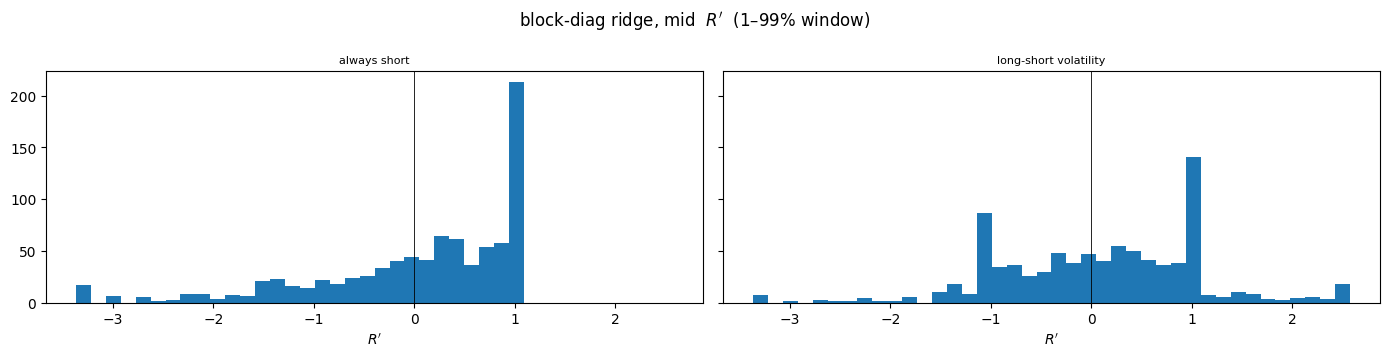

In [11]:
def rule_sizes(px: pd.DataFrame) -> dict[str, pd.Series]:
    return {
        "always short": pd.Series(-1.0, index=px.index),
        "long-short volatility": px["pos"],
    }


def rule_row(r: pd.Series, size: pd.Series) -> pd.Series:
    r = pd.Series(r).astype(float)
    size = pd.Series(size, index=r.index).astype(float)
    x = r.dropna()
    n = int(len(x))
    mu = float(x.mean())
    sd = float(x.std(ddof=1))
    n_buy = int((size > 0).sum())
    n_sz = int(size.notna().sum())
    return pd.Series({
        "n": n,
        "mean": mu,
        "std": sd,
        "min": float(x.min()),
        "25%": float(x.quantile(0.25)),
        "50%": float(x.median()),
        "75%": float(x.quantile(0.75)),
        "max": float(x.max()),
        "skew": float(x.skew()),
        "ex_kurt": float(x.kurt()),
        "t_mean": mu / sd * np.sqrt(n) if sd > 0 else float("nan"),
        "Sharpe_ann": mu / sd * np.sqrt(252.0) if sd > 0 else float("nan"),
        "n_buy": n_buy,
        "pct_buy": 100.0 * n_buy / n_sz if n_sz else float("nan"),
    })


order = [
    "always short",
    "long-short volatility",
]
cols = ["n", "mean", "std", "min", "25%", "50%", "75%", "max",
        "skew", "ex_kurt", "t_mean", "Sharpe_ann", "n_buy", "pct_buy"]
MODEL_ORDER = ["a0", "blk2", "lgbm", "xgb", "lasso_t", "lasso_f", "enet"]

common = None
for tag in MODEL_ORDER:
    idx = books[tag].index
    common = idx if common is None else common.intersection(idx)
common = common.sort_values()
print("days per model:", {LABEL[t]: len(books[t]) for t in MODEL_ORDER})
print("common days:", len(common),
      pd.Timestamp(common.min()), "->", pd.Timestamp(common.max()))

rule_tabs = {}
for tag in MODEL_ORDER:
    px = books[tag]
    sizes = rule_sizes(px)
    rule_tabs[tag] = pd.DataFrame({
        name: rule_row((sizes[name] * px["R"]).loc[common], sizes[name].loc[common])
        for name in order
    }).T[cols]
    rule_tabs[tag].to_csv(OUT / f"rule_table_{tag}.csv")

for name in order:
    if name == "always short":
        # takes no forecast: every model row is identical, so print one
        # anonymous row (and assert the identity instead of trusting it)
        base = rule_tabs[MODEL_ORDER[0]].loc[name]
        for tag in MODEL_ORDER[1:]:
            assert np.allclose(rule_tabs[tag].loc[name], base), name
        tab = pd.DataFrame({"all models": base}).T[cols]
    else:
        tab = pd.DataFrame(
            {LABEL[tag]: rule_tabs[tag].loc[name] for tag in MODEL_ORDER}
        ).T[cols]
    print(name)
    print(tab.to_string())
    print("---")
    safe = "".join(ch if ch.isalnum() else "_" for ch in name)
    tab.to_csv(OUT / f"rule_by_strategy_{safe}.csv")
print("saved per-model rule_table_*.csv and per-rule rule_by_strategy_*.csv in", OUT)

fig, axes = plt.subplots(1, len(order), figsize=(14, 3.6), sharex=True, sharey=True)
px = books["blk2"]
sizes = rule_sizes(px)
pooled = pd.concat([sizes[name] * px["R"] for name in order], axis=0).dropna()
lo, hi = float(pooled.quantile(0.01)), float(pooled.quantile(0.99))
bins = np.linspace(lo, hi, 41)
for ax, name in zip(axes.ravel(), order):
    x = (sizes[name] * px["R"]).dropna()
    ax.hist(x.clip(lo, hi), bins=bins, color="C0", edgecolor="none")
    ax.axvline(0.0, color="k", lw=0.6)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel(r"$R'$")
fig.suptitle("block-diag ridge, mid  $R'$  (1–99% window)")
fig.tight_layout()
fig.savefig(OUT / "rule_hists_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "rule_hists_blk2.png")
display(fig)
plt.close(fig)


## 11. Profit and loss, without compounding

The contracts and positions are those of the rule table. Every series below is a **daily arithmetic** return or profit, summed rather than compounded. The published book is filled at the midpoint quote. Paying the full spread means a long pays the ask and a short receives the bid; a half-spread cost variant charges $\tfrac12(\mathrm{ask}-\mathrm{bid})$ against each trade. Profit in index points is $q(\mathrm{exit}-\mathrm{entry})$, and dollar profit applies the SPXW multiplier of $100$. The margin-scaled return divides dollar profit by an exchange-style short-straddle margin on short days and by the premium paid on long days. The plot is the cumulative sum of dollar profit.

                 rule         variant   unit           n       mean         std          min         25%         50%         75%          max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
         always short   mid premium R return  871.000000   0.020132    1.126834   -10.316049   -0.443536    0.328935    0.931263     1.000000 -2.314322  10.899722  0.527286    0.283620    0.000000   0.000000
         always short    crossed fill return  869.000000  -0.016758    1.170403   -10.954858   -0.491659    0.306209    0.928938     1.000000 -2.363537  11.574814 -0.422072   -0.227288    0.000000   0.000000
         always short  half-spread TC return  871.000000  -0.016799    1.125441   -10.369484   -0.473872    0.293954    0.886394     0.988372 -2.323473  11.011118 -0.440517   -0.236948    0.000000   0.000000
         always short index-point P&L points  871.000000   0.021117    7.885921   -78.370018   -2.390039    1.724805    3.972510    21.890137 -2.602497  16.119768  0.07

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\pnl_cum_usd_blk2.png


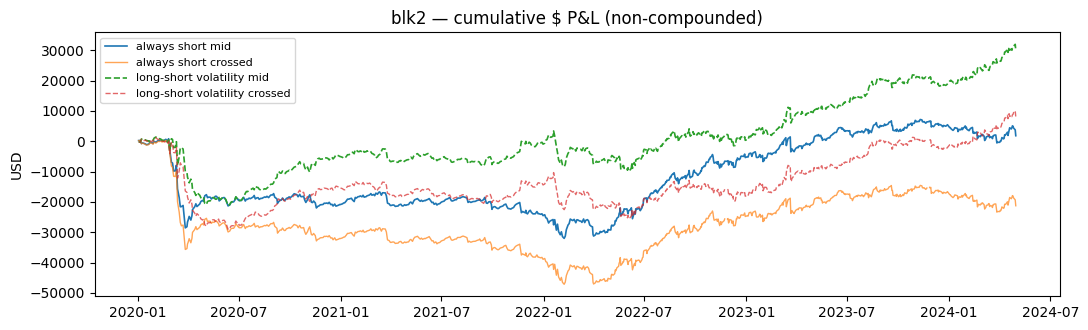

In [12]:
import sys
sys.path.insert(0, str(REPO / "notebooks"))
import atm_straddle_lib as asl

px = books["blk2"].loc[common].copy()
if "bid_entry" not in px.columns:
    px["bid_entry"] = px["bid_c"].astype(float) + px["bid_p"].astype(float)
    px["ask_entry"] = px["ask_c"].astype(float) + px["ask_p"].astype(float)
hs = 0.5 * (px["ask_entry"] - px["bid_entry"])
sizes = rule_sizes(books["blk2"])
rows = []

def add_variant(series, q, rule, variant, unit):
    st = asl.rule_row(series, q)
    rows.append({"rule": rule, "variant": variant, "unit": unit, **st.to_dict()})

for name in ("always short", "long-short volatility"):
    q = sizes[name].loc[common]
    mid = (q * px["R"])
    add_variant(mid, q, name, "mid premium R", "return")
    signq = np.sign(q.replace(0, -1.0))
    crossed = asl.crossed_premium_return(signq, px["exit"], px["bid_entry"], px["ask_entry"]) * q.abs()
    add_variant(crossed, q, name, "crossed fill", "return")
    trade = px["entry"] + signq * hs
    tc = q * (px["exit"] - trade) / px["entry"]
    add_variant(tc, q, name, "half-spread TC", "return")
    pts = asl.points_pnl(q, px["exit"], px["entry"])
    add_variant(pts, q, name, "index-point P&L", "points")
    usd = pts * asl.SPX_MULTIPLIER
    add_variant(usd, q, name, "dollar P&L", "USD")
    margin_pts = [
        asl.cboe_short_straddle_margin_points(S, Kc, Kp, ent)
        for S, Kc, Kp, ent in zip(px["S"], px["K_c"], px["K_p"], px["entry"])
    ]
    margin_pts = pd.Series(margin_pts, index=px.index)
    capital = np.where(q < 0, margin_pts * asl.SPX_MULTIPLIER, px["entry"] * asl.SPX_MULTIPLIER)
    mret = usd / np.maximum(capital, 1e-8)
    add_variant(pd.Series(mret, index=px.index), q, name, "margin-scaled", "return")

var_tab = pd.DataFrame(rows)
print(var_tab.to_string(index=False))
var_tab.to_csv(OUT / "pnl_variants_blk2.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 3.4))
for name, ls in (("always short", "-"), ("long-short volatility", "--")):
    q = sizes[name].loc[common]
    ax.plot(
        px.index,
        asl.points_pnl(q, px["exit"], px["entry"]).cumsum() * asl.SPX_MULTIPLIER,
        ls, lw=1.2, label=f"{name} mid",
    )
    signq = np.sign(q.replace(0, -1.0))
    crossed_usd = (asl.crossed_premium_return(signq, px["exit"], px["bid_entry"], px["ask_entry"]) * q.abs() * px["entry"] * asl.SPX_MULTIPLIER)
    ax.plot(px.index, crossed_usd.cumsum(), ls, lw=1.0, alpha=0.7, label=f"{name} crossed")
ax.set_title("blk2 — cumulative $ P&L (non-compounded)")
ax.set_ylabel("USD")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "pnl_cum_usd_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "pnl_cum_usd_blk2.png")
display(fig)
plt.close(fig)


## 12. Information ratio against always-short

The benchmark is the always-short book, $R^{\mathrm{AS}}_t=-R_t$: one short package every day. The portfolio is the long–short book, $R^p_t=q_t R_t$ with $q_t=\mathrm{sign}(s_t)$.

The **active return** is the daily difference $R^a_t=R^p_t-R^{\mathrm{AS}}_t$. On short days $q_t=-1$ and the two books coincide, so $R^a_t=0$. On buy days the position has flipped from short to long, so $R^a_t=q_tR_t-(-R_t)=(q_t+1)R_t$, which equals $2R_t$ for a $\pm1$ position. The series is those daily differences on the 871 common days.

The table's columns are:

- the **mean active return** (`mean_active`), the sample mean of that daily series, not annualized;
- the **tracking error**, the standard deviation of the active return with $n-1$ in the denominator, reported daily (`te_daily`) and annualized by $\sqrt{252}$ (`te_ann`);
- the **annualized information ratio** (`IR_ann`), $\overline{R^a}/\mathrm{std}(R^a)\times\sqrt{252}$, which equals the mean active return over the annualized tracking error — the Sharpe ratio of the *active* series, not of $R^p$;
- the **$t$-statistic of the active return** (`t_active`), $\overline{R^a}/\mathrm{std}(R^a)\times\sqrt{n}$, the usual test that the mean active return is zero — the same algebra as the $t$-statistic in the rule table, applied to $R^a$; the information ratio and this $t$ move together, but $t$ is not annualized;
- the **correlation to the benchmark** (`corr_to_bench`), $\mathrm{corr}(R^p,R^{\mathrm{AS}})$.

In [13]:
ir_rows = []
for tag in MODEL_ORDER:
    px = books[tag]
    sizes = rule_sizes(px)
    bench = (sizes["always short"] * px["R"]).loc[common]
    for name in ("long-short volatility",):
        port = (sizes[name] * px["R"]).loc[common]
        st = asl.information_ratio(port, bench)
        ir_rows.append({"model": LABEL[tag], "rule": name, **st.to_dict()})
ir_tab = (
    pd.DataFrame(ir_rows)
    .set_index(["rule", "model"])
    .sort_values(by="IR_ann", ascending=False)
    .sort_index(level="rule", sort_remaining=False)
)
print(ir_tab.to_string())
ir_tab.to_csv(OUT / "information_ratio_vs_always_short.csv")
print("IR = active return / tracking error; benchmark is always-short.")


                                                             n  mean_active  te_daily     te_ann    IR_ann  t_active  corr_to_bench
rule                  model                                                                                                        
long-short volatility lasso (fixed 1e-4)            871.000000     0.109708  1.767254  28.054288  0.985457  1.832089      -0.237873
                      block-diag ridge              871.000000     0.095078  1.670489  26.518185  0.903514  1.679746      -0.104451
                      lasso (causally tuned)        871.000000     0.081926  1.575644  25.012566  0.825399  1.534520       0.018516
                      XGBoost                       871.000000     0.078055  1.547942  24.572817  0.800474  1.488183       0.053014
                      LightGBM                      871.000000     0.074126  1.560043  24.764921  0.754281  1.402304       0.038437
                      elastic net (causally tuned)  871.000000     0.060354 

## 13. Does the 15:30 signal predict the settlement return?

The signal is fixed at 15:30 and the package settles at 16:00 the same
day, so the natural test pairs $s_t$ with $R_t$: every input to the
signal is known before the position is taken, and nothing from the
settlement enters it. This is the relation the position rule of §9
trades, measured here as a regression object rather than as a book.
Five checks are printed, all with Newey–West standard errors (six lags)
and no tuning parameters; the percentile rank of $s_t$ is taken among
all days up to and including $t$ once 63 days of history exist, so it
compares today's signal only with the past.

- **Split by sign.** The mean of $R_t$ on days with $s_t>0$ against
  days with $s_t\le 0$, and the $t$-statistic of the difference. This
  is the long–short edge itself.
- **Top third against bottom third** of the rank of $s_t$: the same
  question restricted to the extremes.
- **Regression on the percentile rank** of $s_t$: a monotone relation
  without leverage from extreme values of the signal.
- **Plain least squares** of $R_t$ on the raw signal, shown for
  completeness as the weak instrument it is.
- **Size of the move.** $|R_t|$ on the rank of $s_t$, alone and with
  today's log implied variance added.

The same-day content is a sign effect, not a slope. For the
block-diagonal ridge forecast the package returns about $+0.12$ on
days the forecast sits above implied variance and about $-0.11$ on the
others — a spread near $0.23$ with $t$ near $2.9$ — and the top third
of the ranked signal against the bottom third gives about the same
spread and $t$; every one of the seven forecasts shows the split, with
$t$ between about $1.9$ and $3.3$. The rank regression sees it too
($t$ around $2.6$ for the headline forecast, positive for all seven).
But the raw least-squares slope is null
for the headline forecast ($t$ about $-0.5$; two of the tree forecasts
show a positive slope with $t$ above $3$, at an $R^2$ below $0.001$).
The reason is the shape of $R$: it has a point mass at exactly $-1$ on
the days the package expires worthless and a long right tail, so the
relation lives in the means of two groups — which side of the quoted
variance the forecast stands on — and not in a monotone ordering of
days. A slope is the wrong instrument for that payoff; the sign
split is the right one.

The size of the move is a separate matter. The rank of $s_t$ predicts
$|R_t|$ strongly ($t$ above $4$ for every forecast), but most of that
is the level of implied variance: the rank is high when options are
cheap relative to the forecast, and a cheap straddle moves more per
dollar of premium. With today's log implied variance in the
regression the rank's $t$ falls from about $4.3$ to about $1.7$ for
the headline forecast (to between about $1.3$ and $2.5$ across the
seven), while implied variance itself enters with $t$ near $-3.8$. It
is a price-level effect more than a variance forecast.

The figure at the end of the cell shows the split for the block-diagonal
ridge forecast, anchored on the always-short book (grey bar and dashed
line), the deck's benchmark throughout. Left: the mean settled return on
days the forecast sat below the market's price and on days it sat above,
with error bars. Right: the same mean by decile of the signal's rank — a
step at the sign, and no trend within either half, which is what one bit
of information looks like.

=== SAME DAY: the 15:30 signal against the 16:00 settlement return ===
(1) sign split: mean R_t by sign(s_t)
                       model  mean_R|s>0  mean_R|s<=0      diff    t_diff  n_pos  n_nonpos
          HAR + calendar OLS    0.078543    -0.066882  0.145426  1.858013    280       591
            block-diag ridge    0.122142    -0.110793  0.232935  2.942247    339       532
                    LightGBM    0.114475    -0.084579  0.199054  2.336863    282       589
                     XGBoost    0.123611    -0.086457  0.210068  2.413036    275       596
      lasso (causally tuned)    0.111496    -0.096577  0.208073  2.618967    320       551
          lasso (fixed 1e-4)    0.130898    -0.129077  0.259975  3.295158    365       506
elastic net (causally tuned)    0.086746    -0.077147  0.163894  1.926788    303       568
---
(2) top third vs bottom third of the rank of s_t
                       model  mean_R_top  mean_R_bottom      diff    t_diff  n_top  n_bottom
          HAR + c

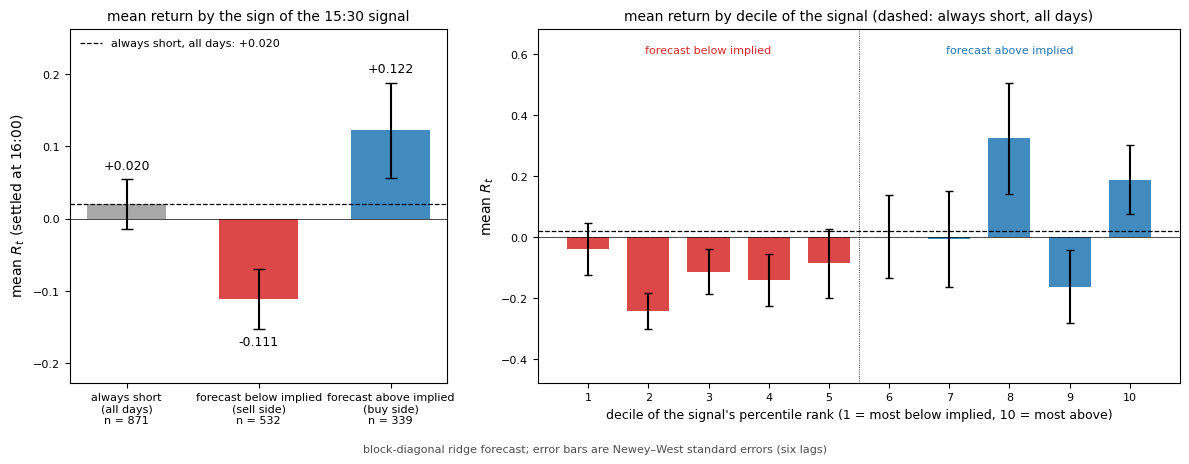

In [14]:
def hac_fit(y, x):
    # least squares with Newey-West (six-lag) standard errors
    return sm.OLS(y, sm.add_constant(x)).fit(cov_type="HAC", cov_kwds={"maxlags": 6})


def battery(x_raw, x_rank, r, iv_log, label):
    # the same checks for whichever version of the signal is passed in:
    # x_raw = the signal, x_rank = its percentile rank, iv_log = log implied variance dated like x
    ok_raw = np.isfinite(x_raw) & np.isfinite(r)
    ok_rk = np.isfinite(x_rank) & np.isfinite(r)
    xr, yr = x_raw[ok_raw].to_numpy(), r[ok_raw].to_numpy()
    rkv, rv_ = x_rank[ok_rk].to_numpy(), r[ok_rk].to_numpy()
    out = {}
    # mean return split by the sign of the signal
    ind = (xr > 0).astype(float)
    fs = hac_fit(yr, ind)
    out["sign"] = {"model": label,
                   "mean_R|s>0": float(yr[ind == 1].mean()),
                   "mean_R|s<=0": float(yr[ind == 0].mean()),
                   "diff": float(fs.params[1]), "t_diff": float(fs.tvalues[1]),
                   "n_pos": int(ind.sum()), "n_nonpos": int((1 - ind).sum())}
    # top third against bottom third of the rank
    hi = rkv > 2.0 / 3.0
    lo = rkv < 1.0 / 3.0
    sel = hi | lo
    ft = hac_fit(rv_[sel], hi[sel].astype(float))
    out["tercile"] = {"model": label,
                      "mean_R_top": float(rv_[hi].mean()),
                      "mean_R_bottom": float(rv_[lo].mean()),
                      "diff": float(ft.params[1]), "t_diff": float(ft.tvalues[1]),
                      "n_top": int(hi.sum()), "n_bottom": int(lo.sum())}
    # regression on the percentile rank
    fit = hac_fit(rv_, rkv)
    out["rank"] = {"model": label, "b_rank": float(fit.params[1]),
                   "t": float(fit.tvalues[1]), "p": float(fit.pvalues[1]), "n": int(fit.nobs)}
    # plain least squares on the raw signal
    fit = hac_fit(yr, xr)
    out["raw"] = {"model": label,
                  "a": float(fit.params[0]), "b": float(fit.params[1]),
                  "t_b": float(fit.tvalues[1]), "p_b": float(fit.pvalues[1]),
                  "R2": float(fit.rsquared), "n": int(fit.nobs)}
    # size of the move on the rank, alone and with the level of implied variance
    fm = hac_fit(np.abs(rv_), rkv)
    out["mag"] = {"model": label, "b_absR": float(fm.params[1]),
                  "t": float(fm.tvalues[1]), "p": float(fm.pvalues[1]),
                  "n": int(fm.nobs)}
    ok3 = ok_rk & np.isfinite(iv_log)
    f3 = hac_fit(np.abs(r[ok3].to_numpy()),
                 np.column_stack([x_rank[ok3].to_numpy(), iv_log[ok3].to_numpy()]))
    out["mag_iv"] = {"model": label,
                     "t_rank_alone": float(fm.tvalues[1]),
                     "t_rank_with_iv": float(f3.tvalues[1]),
                     "t_iv": float(f3.tvalues[2]), "n": int(f3.nobs)}
    return out


same = {k: [] for k in ("sign", "tercile", "rank", "raw", "mag", "mag_iv")}
fig_inputs = None
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    s = px["signal"].astype(float)
    r = px["R"].astype(float)
    iv_log = np.log(px["iv_var"].astype(float))
    rk_same = s.expanding(min_periods=63).rank(pct=True)   # today's signal ranked among all days up to today
    out_same = battery(s, rk_same, r, iv_log, LABEL[tag])
    for k in same:
        same[k].append(out_same[k])
    if tag == "blk2":
        fig_inputs = (s, rk_same, r)

print("=== SAME DAY: the 15:30 signal against the 16:00 settlement return ===")
for key, title in (("sign", "(1) sign split: mean R_t by sign(s_t)"),
                   ("tercile", "(2) top third vs bottom third of the rank of s_t"),
                   ("rank", "(3) regression of R_t on the percentile rank of s_t"),
                   ("raw", "(4) plain least squares of R_t on raw s_t (a weak instrument for a sign effect)"),
                   ("mag", "(5) size of the move: |R_t| on the rank of s_t"),
                   ("mag_iv", "(5) ... with today's log implied variance added")):
    print(title)
    print(pd.DataFrame(same[key]).to_string(index=False))
    print("---")
same_tab = pd.concat({k: pd.DataFrame(v) for k, v in same.items()}, names=["statistic", None]).reset_index(level=0)
same_tab.to_csv(OUT / "sameday_battery.csv", index=False)
pd.DataFrame(same["raw"]).to_csv(OUT / "regression_R_on_signal.csv", index=False)

s, rk_same, r = fig_inputs
s = s.astype(float); r = r.astype(float)
okr = np.isfinite(r)

def mean_se(y):
    # mean with a Newey-West (six-lag) standard error
    f = sm.OLS(np.asarray(y, float), np.ones((len(y), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    return float(f.params[0]), float(f.bse[0])

bench_mean, bench_se = mean_se(-r[okr])   # the always-short book, the deck's benchmark
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1, 1.7]})

# (a) mean settled return by what the 15:30 signal said, against the always-short benchmark
stats = [("always short\n(all days)", bench_mean, bench_se, int(okr.sum()), "0.6")]
for lab, mask, c in (("forecast below implied\n(sell side)", okr & (s <= 0), "C3"),
                     ("forecast above implied\n(buy side)", okr & (s > 0), "C0")):
    m, se = mean_se(r[mask]); stats.append((lab, m, se, int(mask.sum()), c))
top = max(m + se for _, m, se, _, _ in stats); bot = min(m - se for _, m, se, _, _ in stats)
pad = 0.22 * (top - bot)
for i, (lab, m, se, n, c) in enumerate(stats):
    axes[0].bar(i, m, yerr=se, color=c, alpha=0.85, capsize=4, width=0.6)
    axes[0].annotate(f"{m:+.3f}", (i, m + se if m >= 0 else m - se), xytext=(0, 5 if m >= 0 else -5),
                     textcoords="offset points", ha="center", va="bottom" if m >= 0 else "top", fontsize=9)
axes[0].axhline(bench_mean, color="k", lw=0.9, ls="--", label=f"always short, all days: {bench_mean:+.3f}")
axes[0].axhline(0.0, color="k", lw=0.5)
axes[0].set_ylim(bot - pad, top + pad)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels([f"{lab}\nn = {n}" for lab, _, _, n, _ in stats], fontsize=8)
axes[0].set_ylabel(r"mean $R_t$ (settled at 16:00)")
axes[0].set_title("mean return by the sign of the 15:30 signal", fontsize=10)
axes[0].legend(fontsize=8, loc="upper left", frameon=False)

# (b) mean return by decile of the signal's rank, same benchmark
okd = np.isfinite(rk_same) & okr
dec = pd.qcut(rk_same[okd], 10, labels=False) + 1
means, ses = zip(*(mean_se(r[okd][dec == d]) for d in range(1, 11)))
top = max(m + se for m, se in zip(means, ses)); bot = min(m - se for m, se in zip(means, ses))
pad = 0.22 * (top - bot)
axes[1].bar(range(1, 11), means, yerr=ses, color=["C3"] * 5 + ["C0"] * 5, alpha=0.85, capsize=3, width=0.7)
axes[1].axhline(bench_mean, color="k", lw=0.9, ls="--")
axes[1].axhline(0.0, color="k", lw=0.5)
axes[1].axvline(5.5, color="k", lw=0.6, ls=":")
axes[1].set_ylim(bot - pad, top + pad)
axes[1].text(3, top + 0.6 * pad, "forecast below implied", ha="center", va="center", fontsize=8, color="C3")
axes[1].text(8, top + 0.6 * pad, "forecast above implied", ha="center", va="center", fontsize=8, color="C0")
axes[1].set_xticks(range(1, 11))
axes[1].set_xlabel("decile of the signal's percentile rank (1 = most below implied, 10 = most above)", fontsize=9)
axes[1].set_ylabel(r"mean $R_t$")
axes[1].set_title("mean return by decile of the signal (dashed: always short, all days)", fontsize=10)
for ax in axes:
    ax.tick_params(labelsize=8)
fig.text(0.5, 0.005, "block-diagonal ridge forecast; error bars are Newey–West standard errors (six lags)",
         ha="center", fontsize=8, color="0.3")
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(OUT / "sameday_figure_blk2.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 14. Betting a fixed fraction of wealth

Every table so far adds up profits and losses without compounding:
one unit of premium per day. A trader who reinvests instead bets a
fraction $f_t$ of current wealth each day, so wealth compounds,

$$W_T=\prod_{t}\bigl(1+f_t\,q_t R_t\bigr),$$

and the natural objective is the annualized growth rate of log
wealth, $g=252\cdot\overline{\log(1+f_t R'_t)}$, which is what
compounding actually maximizes. One structural fact frames the
exercise: **ruin is one bad day.** Any fraction
$f\ge 1/|\min_t R'_t|$ takes wealth to zero or below on the worst
day, so the short book without wings, whose worst day is near $-10$
premium units, can only ever bet a small fraction of wealth no matter
how good its average return is. (The iron fly of §16 bounds the worst day by construction, which is
exactly what loosens this constraint.)

The fraction is estimated from the book's own past returns only:

$$\hat f_t=\min\!\Bigl(\tfrac{\hat\mu_{t-1}}{\widehat{E[R'^2]}_{t-1}},\,
\tfrac{1}{|\min_{u\le t-1}R'_u|}\Bigr)_{\!+}$$

— the growth-optimal (Kelly) fraction in its quadratic form, held
below the running ruin bound, computed on an expanding window once at
least 63 sessions of history exist and lagged one day. The half
fraction $\hat f_t/2$ is reported alongside as the standard
conservative choice, and for each path we print the growth rate, the
terminal wealth, the drawdown, and the worst single-day wealth factor.

**Two frames for "a fraction of wealth."** The phrase needs a unit
before any growth number can be read. In the **per-premium frame** —
the frame used throughout this section — $f_t$ is the share of wealth
deployed as body premium. For a bought straddle the premium is also
the capital at risk, so on long days the two coincide; for the short
book without wings the capital at risk is unbounded, which is exactly
why the ruin bound above, and not a collateral bound, governs the
admissible fraction. A true **capital-at-risk frame** — $f_t$ as the
share of wealth posted as collateral against the maximum loss, with
the day's return on that capital bounded below by $-1$ by
construction — exists only once the worst day is bounded, and §16 scores it on the
iron fly. One unit of wealth
posted as collateral controls several times less premium exposure
than one unit deployed as premium, and the ratio varies from day to
day, so growth rates compare only within a frame, never across.

blk2 — causally estimated fraction of wealth, 871 common days
rule                     always short  long-short volatility
causal_g_ann                -0.114411               1.043387
causal_terminal              0.673381              36.829878
causal_maxDD                -0.581321              -0.732349
causal_worst_day_factor      0.794366               0.507457
half_g_ann                  -0.036494               0.723831
half_terminal                0.881495              12.204617
half_maxDD                  -0.319277              -0.438413
half_worst_day_factor        0.897183               0.753729
mean_f                       0.013577               0.063128
n                          871.000000             871.000000
saved kelly_summary_<model>.csv in C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530
---
causal growth across models, both rules
                                                    mean_f  causal_g_ann  causal_terminal
rule              

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\kelly_causal_blk2.png


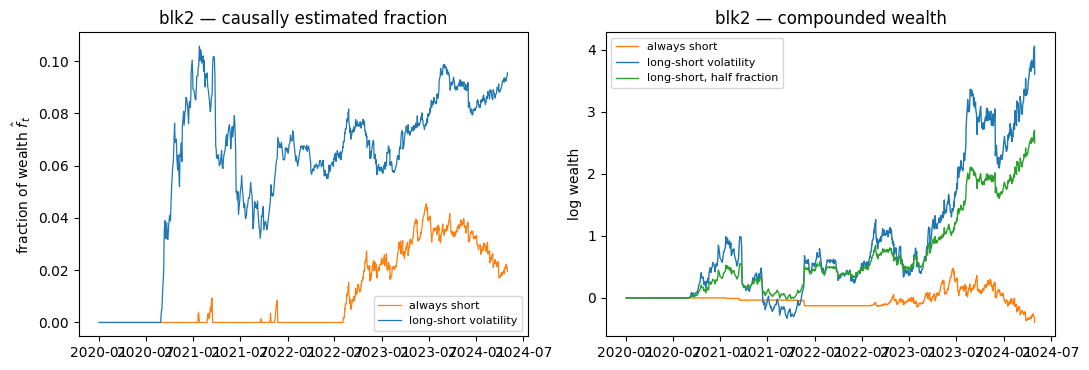

In [15]:
def causal_kelly(rs):
    mu = rs.expanding(min_periods=63).mean().shift(1)
    m2 = (rs**2).expanding(min_periods=63).mean().shift(1)
    cap = 1.0 / rs.expanding(min_periods=1).min().shift(1).abs()
    return np.minimum((mu / m2).clip(lower=0.0), cap).fillna(0.0)

def wealth_row(f, r):
    factors = 1.0 + np.asarray(f) * np.asarray(r)
    assert (factors > 0).all(), "a wealth factor hit zero — ruin"
    w = np.cumprod(factors)
    return pd.Series({
        "g_ann": 252.0 * float(np.mean(np.log(factors))),
        "terminal": float(w[-1]),
        "maxDD": float((w / np.maximum.accumulate(w) - 1.0).min()),
        "worst_day_factor": float(factors.min()),
    })

kelly_rows = {}
for tag in MODEL_ORDER:
    px = books[tag]
    for name, q in rule_sizes(px).items():
        rs = (q * px["R"]).loc[common].astype(float)
        r = rs.to_numpy()
        fk = causal_kelly(rs).to_numpy()
        row = pd.concat({"causal": wealth_row(fk, r), "half": wealth_row(fk / 2, r)})
        row.index = ["_".join(k) for k in row.index]
        row["mean_f"] = float(fk.mean())
        row["n"] = len(r)
        kelly_rows[(name, tag)] = row

kelly_tab = pd.DataFrame(kelly_rows).T
kelly_tab.index = pd.MultiIndex.from_tuples(kelly_tab.index, names=["rule", "model"])
for tag in MODEL_ORDER:
    safe = "".join(ch if ch.isalnum() else "_" for ch in tag)
    kelly_tab.xs(tag, level="model").to_csv(OUT / f"kelly_summary_{safe}.csv")
print("blk2 — causally estimated fraction of wealth, 871 common days")
print(kelly_tab.xs("blk2", level="model").T.to_string())
print("saved kelly_summary_<model>.csv in", OUT)

print("---")
print("causal growth across models, both rules")
spread = kelly_tab[["mean_f", "causal_g_ann", "causal_terminal"]].rename(index=LABEL, level="model")
print(spread.to_string(float_format=lambda x: f"{x:+.4f}"))

for name in ("always short", "long-short volatility"):
    rs = (rule_sizes(books["blk2"])[name] * books["blk2"]["R"]).loc[common].astype(float)
    fk = causal_kelly(rs)
    gy = pd.Series(np.log1p(fk.to_numpy() * rs.to_numpy()), index=rs.index)
    print(f"per-year annualized log-growth, blk2 {name}:")
    print((252.0 * gy.groupby(gy.index.year).mean()).to_string(float_format=lambda x: f"{x:+.3f}"))

px = books["blk2"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name, c in (("always short", "C1"), ("long-short volatility", "C0")):
    rs = (rule_sizes(px)[name] * px["R"]).loc[common].astype(float)
    fk = causal_kelly(rs)
    axes[0].plot(rs.index, fk, lw=0.9, color=c, label=name)
    w = np.cumprod(1.0 + fk.to_numpy() * rs.to_numpy())
    axes[1].plot(rs.index, np.log(w), lw=1.0, color=c, label=name)
rs = (rule_sizes(px)["long-short volatility"] * px["R"]).loc[common].astype(float)
fk = causal_kelly(rs)
w = np.cumprod(1.0 + (fk.to_numpy() / 2) * rs.to_numpy())
axes[1].plot(rs.index, np.log(w), lw=1.0, color="C2", label="long-short, half fraction")
axes[0].set_ylabel(r"fraction of wealth $\hat f_t$")
axes[0].set_title("blk2 — causally estimated fraction")
axes[0].legend(fontsize=8)
axes[1].set_ylabel("log wealth")
axes[1].set_title("blk2 — compounded wealth")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "kelly_causal_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "kelly_causal_blk2.png")
display(fig)
plt.close(fig)


## 15. When does each forecast say buy?

A buy day is one with $q_t>0$. The always-short rule never buys. The
forecasts are compared on the days they share.

                       model  n_buy    pct_buy  mean_R|buy  mean_R|sell  median_|s|_buy
          HAR + calendar OLS    280  32.146958    0.078543    -0.066882        0.000001
            block-diag ridge    339  38.920781    0.122142    -0.110793        0.000001
                    LightGBM    282  32.376579    0.114475    -0.084579        0.000001
                     XGBoost    275  31.572905    0.123611    -0.086457        0.000001
      lasso (causally tuned)    320  36.739380    0.111496    -0.096577        0.000001
          lasso (fixed 1e-4)    365  41.905855    0.130898    -0.129077        0.000001
elastic net (causally tuned)    303  34.787600    0.086746    -0.077147        0.000001
always-short n_buy = 0.
Jaccard of buy-day sets
                              HAR + calendar OLS  block-diag ridge  LightGBM   XGBoost  lasso (causally tuned)  lasso (fixed 1e-4)  elastic net (causally tuned)
HAR + calendar OLS                      1.000000          0.620000  0.678000  0.692000 

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\buy_signal_diag_blk2.png


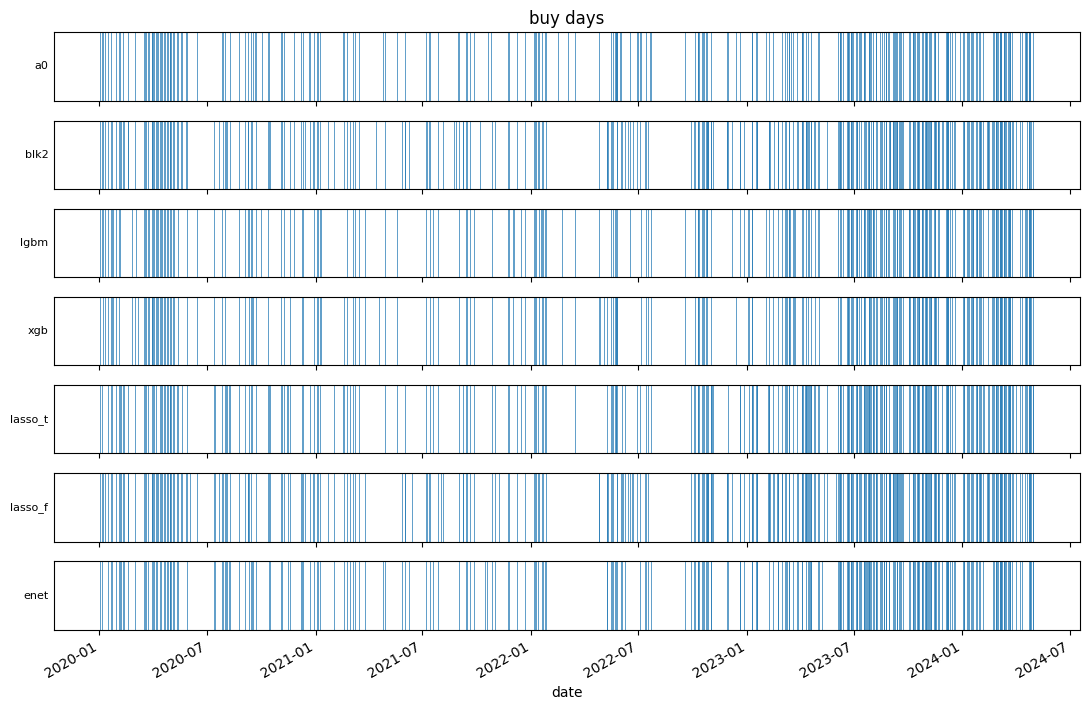

In [16]:
buy = {}
for tag in MODEL_ORDER:
    px = books[tag].loc[common]
    buy[tag] = (px["pos"] > 0)
diag_rows = []
for tag in MODEL_ORDER:
    b = buy[tag]
    px = books[tag].loc[common]
    diag_rows.append({
        "model": LABEL[tag],
        "n_buy": int(b.sum()),
        "pct_buy": 100.0 * float(b.mean()),
        "mean_R|buy": float(px.loc[b, "R"].mean()) if b.any() else float("nan"),
        "mean_R|sell": float(px.loc[~b, "R"].mean()),
        "median_|s|_buy": float(px.loc[b, "signal"].abs().median()) if b.any() else float("nan"),
    })
print(pd.DataFrame(diag_rows).to_string(index=False))
print("always-short n_buy = 0.")

jacc = pd.DataFrame(index=MODEL_ORDER, columns=MODEL_ORDER, dtype=float)
for a in MODEL_ORDER:
    for b in MODEL_ORDER:
        u = buy[a] | buy[b]
        jacc.loc[a, b] = float((buy[a] & buy[b]).sum() / u.sum()) if u.any() else 1.0
jacc.index = [LABEL[t] for t in MODEL_ORDER]
jacc.columns = jacc.index
print("Jaccard of buy-day sets")
print(jacc.round(3).to_string())
jacc.to_csv(OUT / "buy_signal_agreement.csv")
off = jacc.values[np.triu_indices(len(jacc), 1)]
print(f"mean pairwise Jaccard {float(off.mean()):.3f}")

idx = pd.DatetimeIndex(common)
fig, axes = plt.subplots(len(MODEL_ORDER), 1, figsize=(11, 7.2), sharex=True)
for ax, tag in zip(axes, MODEL_ORDER):
    days = idx[buy[tag].to_numpy()]
    ax.vlines(days, 0, 1, color="C0", lw=0.5)
    ax.set_yticks([])
    ax.set_ylabel(tag, rotation=0, ha="right", va="center", fontsize=8)
    ax.set_ylim(0, 1)
axes[-1].set_xlabel("date")
axes[0].set_title("buy days")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(OUT / "buy_signal_diag_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "buy_signal_diag_blk2.png")
display(fig)
plt.close(fig)


## 16. Iron flies — defined risk on the days the book sells

Everything above holds the plain package of §4. On a selling day the
book is short a call and a put with nothing behind them, and its loss
is unbounded. A retail account trading the cash-settled index options
(SPX or XSP) under defined-risk margin cannot hold that position: on a
selling day it must buy a wing on each side — the nearest strike with
a live 15:30 midpoint quote at least $w$ points further out of the
money — so that the short body sits inside two long options, an iron
fly. On a buying day it holds the plain package, whose loss is already
capped at the premium paid; wings there would cap the very payoff the
long position exists to own. This section treats the wings as what
they are for such an account: a **constraint, not a choice**. The
experimental notebook's lab found that, per dollar of premium, wings
cost the book Sharpe at every width it tried, and that the "free
insurance" visible in index points came from one quarter in 2020. The
questions the constraint leaves open are which width to use and how
much of wealth to bet, given that a fly is required. Four widths are
scored: 20 and 30 points, and the 25 and 50 points used in the lab.

**Construction.** The net credit $C$ is the body premium minus the
wing premium; days with $C \le 0$ (a deep wing quote missing, about
one day in a thousand) are dropped and counted. The worst case loses
the larger of the two *actual* wing gaps minus the credit — the
nearest listed wing can sit farther out than the nominal width — and
with that denominator the return on capital at risk is bounded below
by exactly $-1$, which the cell asserts. Returns are reported in the
two frames of §14. Per body premium is the primary frame,

$$R' = \frac{C - \text{settlement payout}}{P_{\mathrm{body}}},$$

the same denominator as the plain rows of §10, so the cost of the
wings reads directly against the plain book on the same days, and the
buy days' plain return is already in this unit. The capital-at-risk
frame, $R'' = (C - \text{payout})/(\text{gap} - C)$, is the fully
collateralized view a margin account actually posts against; it is
reported second because its denominator is smallest on the days with
the richest credit — the high-volatility days — so it overweights
exactly those days and reads cheap tail insurance as a losing trade,
an artifact of the unit. The fraction-of-wealth estimator of §14 is
applied unchanged in both frames; the plain book is compared only in
the per-premium frame, the unit the two share.

**What the constraint costs, and what it leaves.** Per dollar of body
premium the fly costs the long–short book at every width, and the cost
falls as the wings move out: an annualized Sharpe ratio of about 1.36
at 20 points, 1.42 at 25, 1.47 at 30 and 1.54 at 50, against about
1.62 for the plain package on the same 870 days. The wings are touched
on about 7% of fly days at 20 points and 1% at 50. Only the narrowest
fly changes the long–short book's worst day in this unit (about $-4.7$
against $-5.4$); from 25 points out the worst day is where it was,
because the book's worst days are moderate moves on days when the
premium was small, which a wing 25 points away never reaches. The fly
does cut the drawdown in this unit at every width (about $-14$ to
$-16$ against $-18.6$). In index points the wings roughly pay for
themselves at every width — the paired $t$ on their daily cost is
within $\pm 0.6$ — and cut the worst settlement day from about $-78$
points to between $-17$ (20 points) and $-37$ (50 points); the lab
traced that payoff to one quarter in 2020. The always-short control
does not survive the constraint at any width: its thin edge (Sharpe
about 0.27) becomes roughly zero or negative once wings are bought
every day. Under defined-risk margin the book that remains is the
long–short rule.

**How much of wealth to bet.** In the per-premium frame the estimator
of §14 lands on almost the same fraction with wings as without — about
0.054 to 0.062 of wealth deployed as premium, against 0.063 for the
plain package — because it is the estimate of the mean and second
moment, not the ruin bound, that sets the fraction. Wealth compounds
to about 10 times at 20 points, 12 at 25, 15 at 30 and 22 at 50,
against about 34 for the plain package; at the half fraction, about 5
to 9 times. The narrowest fly is again the only one that changes the
worst single day of wealth (a factor of about 0.64 against 0.51). In
the capital-at-risk frame — the collateral a margin account posts —
the fraction is about 0.03 to 0.04 of wealth at every width, the
growth rate about 0.25 to 0.29 a year, and the worst day removes
about 7% of wealth; this is the fully collateralized floor, and its
numbers are not comparable to the per-premium ones. The choice the
constraint leaves is therefore narrow: the widest wing the margin
rule allows costs the least (about 0.08 of Sharpe and a third of the
compounded growth at 50 points) and protects in points but not per
premium; the 20-point fly is the only one that also bounds the
per-premium tail, and it costs about 0.26 of Sharpe and two-thirds of
the compounded growth. Nothing here lets the account bet more of its
wealth than the plain book would.

The figure at the end of the cell shows, for the block-diagonal ridge
forecast, the cumulative per-premium return of the long–short book
with the plain package and with flies at each width, and the
compounded wealth under the causal fraction with and without wings.

width 20: wings on 1291 of 1291 body days; dropped 1 day(s) with credit <= 0 or credit >= wing gap; capital-at-risk floor min -1.0000 (>= -1, 0 violations); settlement beyond a wing on 94 of 1290 days (7.29%)


width 25: wings on 1291 of 1291 body days; dropped 1 day(s) with credit <= 0 or credit >= wing gap; capital-at-risk floor min -1.0000 (>= -1, 0 violations); settlement beyond a wing on 60 of 1290 days (4.65%)


width 30: wings on 1291 of 1291 body days; dropped 1 day(s) with credit <= 0 or credit >= wing gap; capital-at-risk floor min -1.0000 (>= -1, 0 violations); settlement beyond a wing on 39 of 1290 days (3.02%)


width 50: wings on 1291 of 1291 body days; dropped 1 day(s) with credit <= 0 or credit >= wing gap; capital-at-risk floor min -1.0000 (>= -1, 0 violations); settlement beyond a wing on 13 of 1290 days (1.01%)
---
=== width 20, block-diagonal ridge: 870 days = wing days & common; 531 selling days hold the fly, 339 buying days hold the plain package ===
always short, per body premium:
n             870.000000
mean           -0.009758
std             1.008329
min            -6.868821
25%            -0.464481
50%             0.260086
75%             0.822856
max             0.984496
skew           -1.683567
ex_kurt         4.510208
t_mean         -0.285439
Sharpe_ann     -0.153622
n_buy           0.000000
pct_buy         0.000000
long-short volatility, per body premium:
n             870.000000
mean            0.092089
std             1.074198
min            -4.676056
25%            -0.656221
50%             0.101321
75%             0.785929
max            10.316049
skew            1.39943

=== width 25, block-diagonal ridge: 870 days = wing days & common; 531 selling days hold the fly, 339 buying days hold the plain package ===
always short, per body premium:
n             870.000000
mean           -0.004120
std             1.055356
min            -6.868821
25%            -0.458478
50%             0.280150
75%             0.849520
max             0.989637
skew           -1.854750
ex_kurt         5.542655
t_mean         -0.115145
Sharpe_ann     -0.061971
n_buy           0.000000
pct_buy         0.000000
long-short volatility, per body premium:
n             870.000000
mean            0.097805
std             1.095743
min            -5.436565
25%            -0.662943
50%             0.124632
75%             0.800645
max            10.316049
skew            1.164663
ex_kurt        11.526131
t_mean          2.632770
Sharpe_ann      1.416947
n_buy         339.000000
pct_buy        38.965517
capital-at-risk frame (bounded at -1), same days:
  always short: mean -0.00196 Sharpe

=== width 30, block-diagonal ridge: 870 days = wing days & common; 531 selling days hold the fly, 339 buying days hold the plain package ===
always short, per body premium:
n             870.000000
mean            0.000050
std             1.083222
min            -8.183206
25%            -0.451126
50%             0.293132
75%             0.868295
max             0.992453
skew           -2.032926
ex_kurt         7.236500
t_mean          0.001348
Sharpe_ann      0.000726
n_buy           0.000000
pct_buy         0.000000
long-short volatility, per body premium:
n             870.000000
mean            0.102153
std             1.105072
min            -5.436565
25%            -0.675580
50%             0.132159
75%             0.843634
max            10.316049
skew            1.069043
ex_kurt        11.311924
t_mean          2.726591
Sharpe_ann      1.467441
n_buy         339.000000
pct_buy        38.965517
capital-at-risk frame (bounded at -1), same days:
  always short: mean -0.00151 Sharpe

=== width 50, block-diagonal ridge: 870 days = wing days & common; 531 selling days hold the fly, 339 buying days hold the plain package ===
always short, per body premium:
n             870.000000
mean            0.007022
std             1.118524
min           -10.331316
25%            -0.452181
50%             0.318086
75%             0.903675
max             0.994975
skew           -2.341065
ex_kurt        11.247532
t_mean          0.185169
Sharpe_ann      0.099657
n_buy           0.000000
pct_buy         0.000000
long-short volatility, per body premium:
n             870.000000
mean            0.108016
std             1.113820
min            -5.436565
25%            -0.685412
50%             0.137102
75%             0.870201
max            10.316049
skew            1.016043
ex_kurt        10.879897
t_mean          2.860448
Sharpe_ann      1.539482
n_buy         339.000000
pct_buy        38.965517
capital-at-risk frame (bounded at -1), same days:
  always short: mean -0.00154 Sharpe

=== the four widths at a glance, block-diagonal ridge, per body premium ===
 w                  rule  n_fly_days  Sharpe_fly  Sharpe_plain  worst_fly  worst_plain  maxDD_fly  maxDD_plain  pct_beyond_wing  wing_cost_pts_day  t_wing_cost
20          always short         870      -0.154        +0.268     -6.869      -10.316    -25.839      -19.295           +0.067             +0.036       +0.182
25          always short         870      -0.062        +0.268     -6.869      -10.316    -25.712      -19.295           +0.040             -0.007       -0.038
30          always short         870      +0.001        +0.268     -8.183      -10.316    -24.139      -19.295           +0.023             -0.028       -0.182
50          always short         870      +0.100        +0.268    -10.331      -10.316    -21.726      -19.295           +0.010             -0.028       -0.334
20 long-short volatility         531      +1.361        +1.617     -4.676       -5.422    -13.917      -18.550           +0.

block-diagonal ridge (plain-book columns appear only in the per-premium frame, the shared unit):
                                          mean_f  causal_g_ann  causal_terminal  causal_worst_day_factor  half_terminal  plain_mean_f  plain_g_ann  plain_terminal  plain_worst_day_factor
rule                  frame           w                                                                                                                                                   
always short          capital at risk 20  +0.000        -0.000           +0.999                   +0.999         +1.000                                                                   
                      per premium     20  +0.004        -0.079           +0.761                   +0.902         +0.882        +0.013       -0.119          +0.664                  +0.800
long-short volatility capital at risk 20  +0.029        +0.241           +2.300                   +0.933         +1.670                                    

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\ironfly_cum_blk2.png


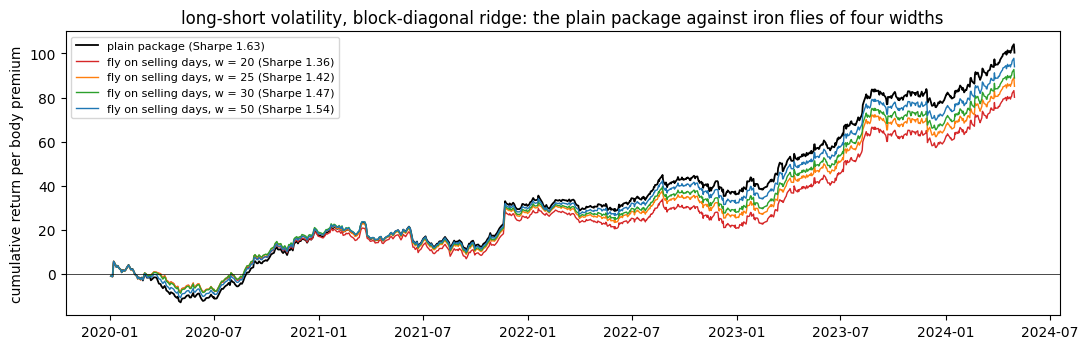

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\ironfly_wealth_blk2.png


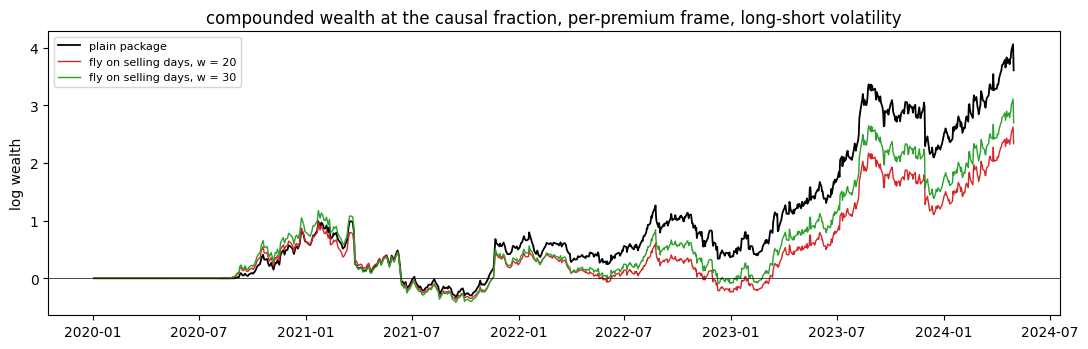

In [17]:
live1530 = book_chain[(book_chain["hhmm"] == "15:30") & np.isfinite(book_chain["mid"]) & (book_chain["mid"] > 0)].copy()
body = atm.reset_index()
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()

def maxdd(x):
    cum = x.cumsum()
    return float((cum - cum.cummax()).min())

def sharpe(x):
    return float(x.mean() / x.std(ddof=1) * np.sqrt(252))

def score_fly(width: float):
    fl = asl.pick_wings(live1530, body, width=width)
    n_wings = len(fl)
    fl = asl.settle_package(fl, close_map)
    fl = fl[np.isfinite(fl["entry_ic"]) & np.isfinite(fl["exit_ic"]) & (fl["width"] > 0)].copy()
    fl["credit"] = fl["entry_ic"]                      # body premium received minus wing premium paid
    # the worst case loses the larger ACTUAL wing gap (the nearest listed wing can sit
    # farther out than the nominal width) minus the credit
    fl["gap_max"] = np.maximum(fl["K_c_wing"] - fl["K_c"], fl["K_p"] - fl["K_p_wing"])
    bad = ~((fl["credit"] > 0) & (fl["credit"] < fl["gap_max"]))
    fl = fl[~bad].copy()
    fl["max_loss"] = fl["gap_max"] - fl["credit"]
    fl["pnl"] = fl["credit"] - fl["exit_ic"]           # index points per package
    fl["R_prem"] = fl["pnl"] / fl["entry_body"]        # primary frame: per body premium
    fl["R_risk"] = fl["pnl"] / fl["max_loss"]          # second frame: per capital at risk
    n_floor = int((fl["R_risk"] < -1.0 - 1e-12).sum())
    assert n_floor == 0, f"{n_floor} day(s) breach the -1 capital-at-risk floor"
    fl["cap_binds"] = (fl["S_close"] >= fl["K_c_wing"]) | (fl["S_close"] <= fl["K_p_wing"])
    if "day" in fl.columns:
        fl = fl.set_index("day")
    fl = fl.sort_index()
    print(f"width {int(width)}: wings on {n_wings} of {len(body)} body days; dropped {int(bad.sum())} day(s) with "
          f"credit <= 0 or credit >= wing gap; capital-at-risk floor min {float(fl['R_risk'].min()):+.4f} "
          f"(>= -1, 0 violations); settlement beyond a wing on {int(fl['cap_binds'].sum())} of {len(fl)} days "
          f"({float(fl['cap_binds'].mean()):.2%})")
    return fl

WIDTHS = (20.0, 25.0, 30.0, 50.0)
flies = {w: score_fly(w) for w in WIDTHS}
print("---")

summary = []
for w, fl in flies.items():
    for tag in MODEL_ORDER:
        px = books[tag]
        j = fl.join(px[["signal", "pos", "R"]], how="inner", rsuffix="_body")
        j = j.loc[j.index.intersection(common)]
        sell = j["pos"] < 0
        series = {
            ("always short", "per premium"): (j["R_prem"], pd.Series(-1.0, index=j.index)),
            ("always short", "capital at risk"): (j["R_risk"], pd.Series(-1.0, index=j.index)),
            ("long-short volatility", "per premium"): (j["R_prem"].where(sell, j["R"]), j["pos"]),
            ("long-short volatility", "capital at risk"): (j["R_risk"].where(sell, j["R"]), j["pos"]),
        }
        tab = pd.DataFrame({key: asl.rule_row(rr, sz) for key, (rr, sz) in series.items()}).T
        tab.index = pd.MultiIndex.from_tuples(tab.index, names=["rule", "units"])
        safe = f"ironfly_w{int(w)}_rule_by_strategy_" + "".join(ch if ch.isalnum() else "_" for ch in tag)
        tab.to_csv(OUT / f"{safe}.csv")
        plain = {"always short": -j["R"], "long-short volatility": j["pos"] * j["R"]}
        naked = (j["entry_body"] - j["exit"]).astype(float)   # the short body alone, index points per package
        hedged = j["pnl"].astype(float)
        drag = naked - hedged                                 # what the wings cost (or return) each day
        for name in ("always short", "long-short volatility"):
            held = pd.Series(True, index=j.index) if name == "always short" else sell
            rr = series[(name, "per premium")][0]
            d = drag[held]
            t_d = sm.OLS(d.to_numpy(), np.ones((len(d), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
            summary.append({"w": int(w), "model": tag, "rule": name, "n": len(j), "n_fly_days": int(held.sum()),
                            "Sharpe_fly": sharpe(rr), "Sharpe_plain": sharpe(plain[name]),
                            "worst_fly": float(rr.min()), "worst_plain": float(plain[name].min()),
                            "maxDD_fly": maxdd(rr), "maxDD_plain": maxdd(plain[name]),
                            "pct_beyond_wing": float(j.loc[held, "cap_binds"].mean()),
                            "wing_cost_pts_day": float(d.mean()), "t_wing_cost": float(t_d.tvalues[0])})
        if tag != "blk2":
            continue
        print(f"=== width {int(w)}, block-diagonal ridge: {len(j)} days = wing days & common; "
              f"{int(sell.sum())} selling days hold the fly, {int((~sell).sum())} buying days hold the plain package ===")
        for name in ("always short", "long-short volatility"):
            rr, sz = series[(name, "per premium")]
            print(f"{name}, per body premium:")
            print(asl.rule_row(rr, sz).to_string())
        print("capital-at-risk frame (bounded at -1), same days:")
        for name in ("always short", "long-short volatility"):
            rr, _ = series[(name, "capital at risk")]
            print(f"  {name}: mean {float(rr.mean()):+.5f} Sharpe {sharpe(rr):+.3f} min {float(rr.min()):+.3f} max {float(rr.max()):+.3f}")
        print("fly vs plain package, same days, per body premium:")
        for name in ("always short", "long-short volatility"):
            rr, _ = series[(name, "per premium")]
            pl = plain[name]
            print(f"  {name}: mean {float(rr.mean()):+.5f} Sharpe {sharpe(rr):+.3f} worst {float(rr.min()):+.3f} "
                  f"maxDD {maxdd(rr):+.2f} | plain: mean {float(pl.mean()):+.5f} Sharpe {sharpe(pl):+.3f} "
                  f"worst {float(pl.min()):+.3f} maxDD {maxdd(pl):+.2f}")
        t_all = sm.OLS(drag.to_numpy(), np.ones((len(drag), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
        jb = j["cap_binds"]
        worst10 = naked.nsmallest(10).index
        print(f"the insurance in index points per package, short body every day, {len(j)} days:")
        print(f"  wing cost {float(drag.mean()):+.3f}/day (paired Newey-West t {float(t_all.tvalues[0]):+.2f}); "
              f"worst day naked {float(naked.min()):+.1f} vs fly {float(hedged.min()):+.1f}; "
              f"maxDD naked {maxdd(naked):+.1f} vs fly {maxdd(hedged):+.1f}")
        print(f"  settlement beyond a wing on {int(jb.sum())} of these days: points returned there "
              f"{float((hedged - naked)[jb].sum()):+.1f}; over the 10 worst naked days {float((hedged - naked)[worst10].sum()):+.1f}")
        print("---")

summary = pd.DataFrame(summary)
summary.to_csv(OUT / "ironfly_summary.csv", index=False)
print("=== the four widths at a glance, block-diagonal ridge, per body premium ===")
cols = ["w", "rule", "n_fly_days", "Sharpe_fly", "Sharpe_plain", "worst_fly", "worst_plain", "maxDD_fly", "maxDD_plain",
        "pct_beyond_wing", "wing_cost_pts_day", "t_wing_cost"]
print(summary[summary["model"] == "blk2"][cols].sort_values(["rule", "w"]).to_string(index=False, float_format=lambda x: f"{x:+.3f}"))
print("saved ironfly_w<w>_rule_by_strategy_<model>.csv and ironfly_summary.csv in", OUT)
print("---")

print("=== fraction of wealth (estimator of section 14) on the fly book; frame named first ===")
kv_rows = {}
for w, fl in flies.items():
    for tag in MODEL_ORDER:
        px = books[tag]
        j = fl.join(px[["pos", "R"]], how="inner", rsuffix="_body")
        j = j.loc[j.index.intersection(common)]
        sell = j["pos"] < 0
        frames = {
            ("always short", "capital at risk"): j["R_risk"],
            ("always short", "per premium"): j["R_prem"],
            ("long-short volatility", "capital at risk"): j["R_risk"].where(sell, j["R"]),
            ("long-short volatility", "per premium"): j["R_prem"].where(sell, j["R"]),
        }
        for (name, frame), rs in frames.items():
            rs = rs.astype(float)
            rv = rs.to_numpy()
            fk = causal_kelly(rs).to_numpy()
            row = pd.concat({"causal": wealth_row(fk, rv), "half": wealth_row(fk / 2, rv)})
            row.index = ["_".join(k) for k in row.index]
            row["mean_f"] = float(fk.mean())
            if frame == "per premium":
                # the plain book is compared ONLY in the shared premium unit
                ru = (-px["R"] if name == "always short" else px["pos"] * px["R"]).loc[rs.index].astype(float)
                fku = causal_kelly(ru).to_numpy()
                unc = wealth_row(fku, ru.to_numpy())
                row["plain_g_ann"] = unc["g_ann"]
                row["plain_terminal"] = unc["terminal"]
                row["plain_worst_day_factor"] = unc["worst_day_factor"]
                row["plain_mean_f"] = float(fku.mean())
            kv_rows[(name, frame, tag, int(w))] = row
kv = pd.DataFrame(kv_rows).T
kv.index = pd.MultiIndex.from_tuples(kv.index, names=["rule", "frame", "model", "w"])
for tag in MODEL_ORDER:
    safe = "".join(ch if ch.isalnum() else "_" for ch in tag)
    kv.xs(tag, level="model").to_csv(OUT / f"ironfly_kelly_{safe}.csv")
show = ["mean_f", "causal_g_ann", "causal_terminal", "causal_worst_day_factor", "half_terminal",
        "plain_mean_f", "plain_g_ann", "plain_terminal", "plain_worst_day_factor"]
print("block-diagonal ridge (plain-book columns appear only in the per-premium frame, the shared unit):")
print(kv.xs("blk2", level="model")[show].to_string(float_format=lambda x: f"{x:+.3f}", na_rep=""))
print("saved ironfly_kelly_<model>.csv in", OUT)

px = books["blk2"]
fig, ax = plt.subplots(figsize=(11, 3.6))
rp = (px["pos"] * px["R"]).loc[common]
ax.plot(rp.index, rp.cumsum().values, color="k", lw=1.3, label=f"plain package (Sharpe {sharpe(rp):.2f})")
for (w, fl), c in zip(flies.items(), ("C3", "C1", "C2", "C0")):
    j = fl.join(px[["pos", "R"]], how="inner", rsuffix="_body")
    j = j.loc[j.index.intersection(common)]
    ls = j["R_prem"].where(j["pos"] < 0, j["R"])
    ax.plot(ls.index, ls.cumsum().values, color=c, lw=1.0, label=f"fly on selling days, w = {int(w)} (Sharpe {sharpe(ls):.2f})")
ax.axhline(0.0, color="k", lw=0.5)
ax.set_ylabel("cumulative return per body premium")
ax.set_title("long-short volatility, block-diagonal ridge: the plain package against iron flies of four widths")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "ironfly_cum_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "ironfly_cum_blk2.png")
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(11, 3.6))
rp = (px["pos"] * px["R"]).loc[common].astype(float)
fk = causal_kelly(rp).to_numpy()
ax.plot(rp.index, np.log(np.cumprod(1.0 + fk * rp.to_numpy())), color="k", lw=1.3, label="plain package")
for w, c in ((20.0, "C3"), (30.0, "C2")):
    j = flies[w].join(px[["pos", "R"]], how="inner", rsuffix="_body")
    j = j.loc[j.index.intersection(common)]
    ls = j["R_prem"].where(j["pos"] < 0, j["R"]).astype(float)
    fk = causal_kelly(ls).to_numpy()
    ax.plot(ls.index, np.log(np.cumprod(1.0 + fk * ls.to_numpy())), color=c, lw=1.0, label=f"fly on selling days, w = {int(w)}")
ax.axhline(0.0, color="k", lw=0.5)
ax.set_ylabel("log wealth")
ax.set_title("compounded wealth at the causal fraction, per-premium frame, long-short volatility")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "ironfly_wealth_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "ironfly_wealth_blk2.png")
display(fig)
plt.close(fig)


## 17. Checking one row by hand

The columns of a single row map onto the construction as follows.

- `K_c >= S` and `K_p <= S` at 15:30: the call strike sits at or
  above the spot and the put strike at or below it.
- `entry` is the 15:30 midpoint quote of the package, `mid_c + mid_p`.
- `exit` is the cash settlement,
  `max(S_close - K_c, 0) + max(K_p - S_close, 0)`, with `S_close`
  the official close from yfinance `^GSPC`.
- `R` is `exit/entry - 1`.
- `yhat` is the forecast on the fitted scale, $\widehat{\sqrt{RV/B}}$;
  `rv_hat = (m^2 + s2) * B` converts it to a 30-minute variance.
- The quoted implied volatility is hourly, so
  `iv_30 = iv_hourly / sqrt(2)` and `iv_var = iv_30**2`.
- `signal = rv_hat - iv_var`; the variance risk premium is
  $\mathrm{VRP}=-s$. The long-short volatility position `pos` is $+1$
  when the signal is positive and $-1$ otherwise.

---

*Housekeeping note (2026-09-02, not analysis).* Repo state to clean up
later. The two working directories are worktrees of one repo on sibling
branches that diverged at `5db8240`: this branch
(`grok/0dte-professor-notes`, +15) carries all the notebook work and
the close-option writeup prose; `paper2` (+1, `d3809a4`) carries the
F$_t$-measurability scorer fixes and the honest options macros in
`writeup/generated/`. The writeup therefore has two truths pending
consolidation (both options narratives are parked, so nothing renders
wrong yet). Plan sketched: (a) merge this branch into `paper2` (merge,
not rebase) and fast-forward this branch to the merge; (b) fast-forward
local `main` (behind `origin/main` by 6 campaign-sync commits that are
already ancestors of `paper2`); (c) fix `paper2`'s upstream (tracks
`origin/main`, should be `origin/paper2`) and delete-or-archive the two
dead local branches (`edge-features-legibility`,
`prop-exploration-2026-07-02`, upstreams gone); (d) untrack LaTeX aux
and volatile `.hpc` state via `.gitignore` to stop the chronic dirty
tree; (e) review the real uncommitted diffs in `harxhar-clean`
(`experiments/run_geometry_local.py`, spec/pack jsons) before touching
anything. Open decision: one unified line vs keeping this branch as a
deliberate fork; delete vs archive for the dead branches.